In [1]:
import copy

import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from search.parallel_gradient import ParallelGradientDescent
from search.tree import CoordinateDescent, WeightedCoordinateDescent
from utils.sampling import BatchNegativeSampler
from utils.transform_sequence import TransformSequence

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
#print pytorch version
print(torch.__version__)

2.8.0+cu126


In [3]:
#look for experiment files in parents
import os
path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)


In [4]:
experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")

In [5]:
dataset ="bigger_mnist"
default_architecutre_mapping = {
    "mnist":"resnet_small",
    "bigger_mnist":"resnet_small",
    "emnist": "extended_resnet_small",
    "bigger_emnist":"bigger_extended_resnet_small",
    "coil100":"coil_resnet_small",
    "tu_berlin":"bi_lstm",
    "modelnet10":"pointnetplus",

}



architecture = default_architecutre_mapping[dataset]

In [6]:
from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info,get_dataset

dataset_info = get_dataset_info(dataset)
dataset_dict = get_dataset(dataset_info,path=experiment_files_path_data)


In [7]:
dataset_info

Box({'input_size': (1, 40, 40), 'num_classes': 10, 'transform_seq_name': 'biggermnist_default', 'datatype': 'image', 'name': 'bigger_mnist', 'resample_method': 'grid_resample', 'pad': 6, 'epochs': 100, 'batch_size': 128, 'batch_size_search': 1024})

In [8]:
dataset_dict.keys()

dict_keys(['train_dataset', 'val_dataset', 'test_dataset', 'train_loader', 'train_loader_no_shuffle', 'val_loader', 'test_loader', 'shuffle_val_loader', 'n_classes', 'train_loader_transformed', 'train_loader_transformed_no_shuffle', 'val_loader_transformed', 'test_loader_transformed', 'shuffle_val_loader_transformed', 'train_loader_augmented'])

In [9]:
dataset_train = dataset_dict['train_dataset']
dataset_val = dataset_dict['val_dataset']
dataset_test = dataset_dict['test_dataset']
train_loader = dataset_dict['train_loader']
val_loader = dataset_dict['val_loader']
test_loader = dataset_dict['test_loader']
n_classes = dataset_info.num_classes
train_loader_transformed = dataset_dict['train_loader_transformed']
val_loader_transformed = dataset_dict['val_loader_transformed']
test_loader_transformed = dataset_dict['test_loader_transformed']
train_loader_no_shuffle = dataset_dict['train_loader_no_shuffle']



In [10]:
batch_size = next(iter(train_loader))[0].shape[0]

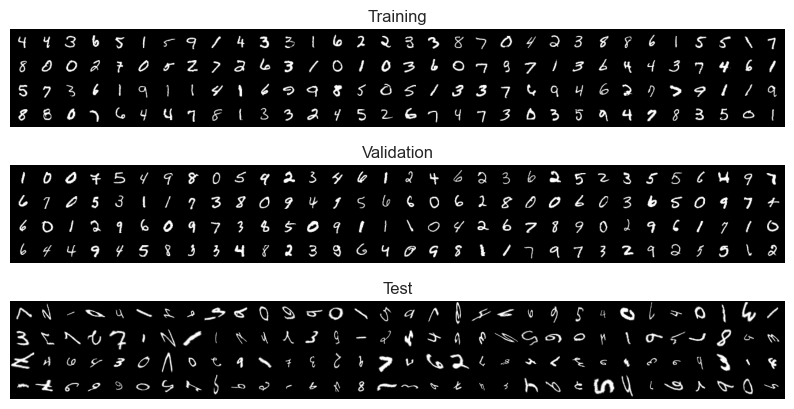

In [11]:
#test images
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 5))

axs[0].imshow(torchvision.utils.make_grid(next(iter(train_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[1].imshow(torchvision.utils.make_grid(next(iter(val_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[2].imshow(torchvision.utils.make_grid(next(iter(test_loader_transformed))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[0].set_title('Training')
axs[1].set_title('Validation')
axs[2].set_title('Test')

for ax in axs.flat:
    ax.axis('off')

In [12]:
from experiment_thesis.main import train_and_get_model
from experiment_thesis.dataset_preperation.basic_networks import get_network
from utils.eval.main_model import evaluate_base_model

In [13]:
model_dir_path = os.path.join(current_path, "experiment_files", "models")
embedding_cache_path = os.path.join(current_path, "experiment_files", "embedding_cache")

In [14]:
model = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}"
cache_name_train= f"{dataset}_{architecture}_embedding_cache_train"

train_and_get_model(model,model_dir_path,modelname, train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": 100,
        "precision": "16-mixed",
},load_if_exists=True)


res = evaluate_base_model(model, test_loader_transformed, device)
print(res)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small.safetensors


{'accuracy': 0.37689998745918274, 'f2_macro': 0.37094762921333313, 'f2_micro': 0.37689998745918274, 'f2_weighted': 0.3730011582374573}


In [15]:
dataset_info

Box({'input_size': (1, 40, 40), 'num_classes': 10, 'transform_seq_name': 'biggermnist_default', 'datatype': 'image', 'name': 'bigger_mnist', 'resample_method': 'grid_resample', 'pad': 6, 'epochs': 100, 'batch_size': 128, 'batch_size_search': 1024})

In [16]:
from experiment_thesis.dataset_preperation.transformation import get_transformation_sequence_images
if dataset_info.transform_seq_name is not None and dataset_info.datatype == "image":
    transform_seq = get_transformation_sequence_images(
                name=dataset_info.transform_seq_name,
                resample_method=dataset_info.resample_method
    ).cuda()

In [17]:
print(list(model.named_modules()))

[('', FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2):

In [18]:
model.eval().cuda()

FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [19]:
from torch.utils.data import SequentialSampler
from embedding_cache import LayerEmbeddingCache
transform_name = dataset_info.transform_seq_name

cache_name_train = f"{dataset}_{architecture}_{transform_name}_embedding_cache_train"

cache_train = LayerEmbeddingCache(model,train_loader_no_shuffle,cache_dir=os.path.join(embedding_cache_path,cache_name_train))
embeddings_t,final_t,classes_t = cache_train.__call__("fc",capture_modes='input',flatten=True)

In [20]:
dual_output_model = cache_train.make_wrapper("fc",capture_modes='input',concat=False,flatten=True)


In [21]:
from utils.eval.ood_performance import evaluate_confidence_module, evaluate_confidence_and_search
from search import shgo



In [22]:
from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence, PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence,PerClassKNNConfidence

from confidence.input_transform import InputTransformImage,PCAInputModule,RandomProjectionModule
input_transform_image = InputTransformImage((3,3),(128,7,7))
input_transform_pca = PCAInputModule(512)
input_transform_random = RandomProjectionModule(512,method="gaussian")


nn_pytorch_pretrained = PerClassKNNConfidence(metric="cosine",input_transform=None)
nn_pytorch_pretrained.fit(embeddings_t,classes_t)
nn_pytorch_pretrained.cuda()

conf_split_pretrained = PredictedSplitConfidence(nn_pytorch_pretrained,EnergyConfidence(), mult=False,b=0.0)
conf_mod_nn_pytorch_pretrained = SinglePassConfidence(dual_output_model,conf_split_pretrained,index=1)
problem_nn_pytorch_pretrained = TransformationProblem(conf_mod_nn_pytorch_pretrained,transform_seq,consolidate_method="consolidate_simple")


In [23]:
from search.parallel_gradient import ParallelGradientDescent
from search.simulated_anealing import ParallelSimulatedAnnealing

In [24]:
repeats=10
overwrite = False

In [25]:
from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search

ps = ParallelSimulatedAnnealing(max_iterations=12,initial_temp=0.0,neighbor_hood_size=0.25,project_param=True,parallel_runs=10)
conf_energy= SinglePassConfidence(model, EnergyConfidence())
problem_energy= TransformationProblem(conf_energy, transform_seq, consolidate_method="consolidate_simple")

path = os.path.join(current_path, "experiment_files", "results",f"{dataset}","experiment_restrictive")
modelname = f"{architecture}_restricted_domain_psa_default"
complete_path = os.path.join(path, modelname + ".json")

load_or_run_evaluate_confidence_and_search(model, ps, problem_energy, test_loader_transformed, max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)

{'repeats': 10,
 'accuracy_mean': 0.7511900067329407,
 'accuracy_std': 0.0044528343714773655,
 'accuracy_se': 0.0014081098657352778,
 'f2_macro_mean': 0.7453253269195557,
 'f2_macro_std': 0.0046019223518669605,
 'f2_macro_se': 0.0014552556247138416,
 'f2_micro_mean': 0.7511900067329407,
 'f2_micro_std': 0.0044528343714773655,
 'f2_micro_se': 0.0014081098657352778,
 'f2_weighted_mean': 0.7475232481956482,
 'f2_weighted_std': 0.004520623944699764,
 'f2_weighted_se': 0.0014295468110346319,
 'per_run': [{'accuracy': 0.7477999925613403,
   'f2_macro': 0.7414902448654175,
   'f2_micro': 0.7477999925613403,
   'f2_weighted': 0.743871808052063,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.7472000122070312,
   'f2_macro': 0.7413479685783386,
   'f2_micro': 0.7472000122070312,
   'f2_weighted': 0.7436541318893433,
   'per_sample_errors': None,
   'per_sample_mat

In [26]:
ps = ParallelSimulatedAnnealing(max_iterations=12,initial_temp=0.0,neighbor_hood_size=0.25,project_param=False,parallel_runs=10)
conf_energy= SinglePassConfidence(model, EnergyConfidence())
problem_energy= TransformationProblem(conf_energy, transform_seq, consolidate_method="consolidate_simple")

complete_path = os.path.join(path, f"{architecture}_unrestricted_domain_psa_default" + ".json")
load_or_run_evaluate_confidence_and_search(model, ps, problem_energy, test_loader_transformed,
                                           max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)


{'repeats': 10,
 'accuracy_mean': 0.7326199412345886,
 'accuracy_std': 0.003955259919166565,
 'accuracy_se': 0.0012507630082539817,
 'f2_macro_mean': 0.7255800366401672,
 'f2_macro_std': 0.004166786093264818,
 'f2_macro_se': 0.001317653457743161,
 'f2_micro_mean': 0.7326199412345886,
 'f2_micro_std': 0.003955259919166565,
 'f2_micro_se': 0.0012507630082539817,
 'f2_weighted_mean': 0.7279477715492249,
 'f2_weighted_std': 0.004135551396757364,
 'f2_weighted_se': 0.001307776179444395,
 'per_run': [{'accuracy': 0.7404000163078308,
   'f2_macro': 0.7336727380752563,
   'f2_micro': 0.7404000163078308,
   'f2_weighted': 0.7358677983283997,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.7293999791145325,
   'f2_macro': 0.7220926284790039,
   'f2_micro': 0.7293999791145325,
   'f2_weighted': 0.7245672345161438,
   'per_sample_errors': None,
   'per_sample_matrice

In [27]:
from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search

ps = ParallelSimulatedAnnealing(max_iterations=24,initial_temp=0.0,neighbor_hood_size=0.25,project_param=True,parallel_runs=20)
conf_energy= SinglePassConfidence(model, EnergyConfidence())
problem_energy= TransformationProblem(conf_energy, transform_seq, consolidate_method="consolidate_simple")

path = os.path.join(current_path, "experiment_files", "results",f"{dataset}","experiment_restrictive")
modelname = f"{architecture}_restricted_domain_psa_default_480"
complete_path = os.path.join(path, modelname + ".json")

load_or_run_evaluate_confidence_and_search(model, ps, problem_energy, test_loader_transformed, max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)

{'repeats': 10,
 'accuracy_mean': 0.8250199556350708,
 'accuracy_std': 0.002553344238549471,
 'accuracy_se': 0.0008074383444284632,
 'f2_macro_mean': 0.8208199739456177,
 'f2_macro_std': 0.002608617302030325,
 'f2_macro_se': 0.0008249172218139206,
 'f2_micro_mean': 0.8250199556350708,
 'f2_micro_std': 0.002553344238549471,
 'f2_micro_se': 0.0008074383444284632,
 'f2_weighted_mean': 0.8222368955612183,
 'f2_weighted_std': 0.002576367696747184,
 'f2_weighted_se': 0.000814719001180308,
 'per_run': [{'accuracy': 0.829800009727478,
   'f2_macro': 0.8256807327270508,
   'f2_micro': 0.829800009727478,
   'f2_weighted': 0.8270653486251831,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.8248999714851379,
   'f2_macro': 0.8206483125686646,
   'f2_micro': 0.8248999714851379,
   'f2_weighted': 0.8221509456634521,
   'per_sample_errors': None,
   'per_sample_matrices

In [28]:
ps = ParallelSimulatedAnnealing(max_iterations=24,initial_temp=0.0,neighbor_hood_size=0.25,project_param=False,parallel_runs=20)
conf_energy= SinglePassConfidence(model, EnergyConfidence())
problem_energy= TransformationProblem(conf_energy, transform_seq, consolidate_method="consolidate_simple")

complete_path = os.path.join(path, f"{architecture}_unrestricted_domain_psa_default_480" + ".json")
load_or_run_evaluate_confidence_and_search(model, ps, problem_energy, test_loader_transformed,
                                           max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)


{'repeats': 10,
 'accuracy_mean': 0.786270022392273,
 'accuracy_std': 0.0022126068361103535,
 'accuracy_se': 0.0006996877168567609,
 'f2_macro_mean': 0.780548632144928,
 'f2_macro_std': 0.002311804099008441,
 'f2_macro_se': 0.0007310566456980081,
 'f2_micro_mean': 0.786270022392273,
 'f2_micro_std': 0.0022126068361103535,
 'f2_micro_se': 0.0006996877168567609,
 'f2_weighted_mean': 0.7822297811508179,
 'f2_weighted_std': 0.002261550398543477,
 'f2_weighted_se': 0.0007151650302658932,
 'per_run': [{'accuracy': 0.7847999930381775,
   'f2_macro': 0.7793084383010864,
   'f2_micro': 0.7847999930381775,
   'f2_weighted': 0.7809697389602661,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.7821000218391418,
   'f2_macro': 0.7760652303695679,
   'f2_micro': 0.7821000218391418,
   'f2_weighted': 0.7778534889221191,
   'per_sample_errors': None,
   'per_sample_matric

In [29]:
#now for knn 480
ps = ParallelSimulatedAnnealing(max_iterations=24,initial_temp=0.0,neighbor_hood_size=0.25,project_param=True,parallel_runs=20)
problem_energy= TransformationProblem(conf_mod_nn_pytorch_pretrained,transform_seq,
consolidate_method="consolidate_simple")
complete_path = os.path.join(path, f"{architecture}_restricted_domain_psa_knn_480" + ".json")
load_or_run_evaluate_confidence_and_search(model, ps, problem_energy, test_loader_transformed,
                                           max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)


{'repeats': 10,
 'accuracy_mean': 0.8943400382995605,
 'accuracy_std': 0.001768992398865521,
 'accuracy_se': 0.0005594045143940108,
 'f2_macro_mean': 0.893007755279541,
 'f2_macro_std': 0.0017826794646680355,
 'f2_macro_se': 0.0005637327446360654,
 'f2_micro_mean': 0.8943400382995605,
 'f2_micro_std': 0.001768992398865521,
 'f2_micro_se': 0.0005594045143940108,
 'f2_weighted_mean': 0.8938204646110535,
 'f2_weighted_std': 0.0017866897396743298,
 'f2_weighted_se': 0.000565000904942419,
 'per_run': [{'accuracy': 0.894599974155426,
   'f2_macro': 0.8933358192443848,
   'f2_micro': 0.894599974155426,
   'f2_weighted': 0.8940788507461548,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.8974000215530396,
   'f2_macro': 0.896060585975647,
   'f2_micro': 0.8974000215530396,
   'f2_weighted': 0.8968192338943481,
   'per_sample_errors': None,
   'per_sample_matrices

In [30]:
ps = ParallelSimulatedAnnealing(max_iterations=24,initial_temp=0.0,neighbor_hood_size=0.25,project_param=False,parallel_runs=20)
problem_energy= TransformationProblem(conf_mod_nn_pytorch_pretrained,transform_seq,
consolidate_method="consolidate_simple")
complete_path = os.path.join(path, f"{architecture}_unrestricted_domain_psa_knn_480" + ".json")
load_or_run_evaluate_confidence_and_search(model, ps, problem_energy, test_loader_transformed,
                                           max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)

{'repeats': 10,
 'accuracy_mean': 0.8902300000190735,
 'accuracy_std': 0.001717260922305286,
 'accuracy_se': 0.0005430455851286152,
 'f2_macro_mean': 0.8888673782348633,
 'f2_macro_std': 0.0017995162634178996,
 'f2_macro_se': 0.00056905700789161,
 'f2_micro_mean': 0.8902300000190735,
 'f2_micro_std': 0.001717260922305286,
 'f2_micro_se': 0.0005430455851286152,
 'f2_weighted_mean': 0.8896476626396179,
 'f2_weighted_std': 0.0017776158638298512,
 'f2_weighted_se': 0.0005621314934550054,
 'per_run': [{'accuracy': 0.887499988079071,
   'f2_macro': 0.8860419988632202,
   'f2_micro': 0.887499988079071,
   'f2_weighted': 0.8869360685348511,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.8910999894142151,
   'f2_macro': 0.8899689316749573,
   'f2_micro': 0.8910999894142151,
   'f2_weighted': 0.8905948400497437,
   'per_sample_errors': None,
   'per_sample_matrice

In [31]:
ps = ParallelSimulatedAnnealing(max_iterations=12,initial_temp=0.0,neighbor_hood_size=0.25,project_param=True,parallel_runs=10)

problem_energy= TransformationProblem(conf_mod_nn_pytorch_pretrained,transform_seq,
consolidate_method="consolidate_simple")
complete_path = os.path.join(path, f"{architecture}_restricted_domain_psa_knn" + ".json")

load_or_run_evaluate_confidence_and_search(model, ps, problem_energy, test_loader_transformed,
                                           max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)


{'repeats': 10,
 'accuracy_mean': 0.8156599998474121,
 'accuracy_std': 0.0035211110953241587,
 'accuracy_se': 0.0011134730955714598,
 'f2_macro_mean': 0.8127655982971191,
 'f2_macro_std': 0.0036068034823983908,
 'f2_macro_se': 0.0011405714077005946,
 'f2_micro_mean': 0.8156599998474121,
 'f2_micro_std': 0.0035211110953241587,
 'f2_micro_se': 0.0011134730955714598,
 'f2_weighted_mean': 0.8144484758377075,
 'f2_weighted_std': 0.0035744335036724806,
 'f2_weighted_se': 0.0011303351216420874,
 'per_run': [{'accuracy': 0.817799985408783,
   'f2_macro': 0.815078616142273,
   'f2_micro': 0.817799985408783,
   'f2_weighted': 0.8166550993919373,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.817799985408783,
   'f2_macro': 0.8149062395095825,
   'f2_micro': 0.817799985408783,
   'f2_weighted': 0.8167566061019897,
   'per_sample_errors': None,
   'per_sample_matric

In [32]:
ps = ParallelSimulatedAnnealing(max_iterations=12,initial_temp=0.0,neighbor_hood_size=0.25,project_param=False,parallel_runs=10)

problem_energy= TransformationProblem(conf_mod_nn_pytorch_pretrained,transform_seq,
consolidate_method="consolidate_simple")
complete_path = os.path.join(path, f"{architecture}_unrestricted_domain_psa_knn" + ".json")
load_or_run_evaluate_confidence_and_search(model, ps, problem_energy, test_loader_transformed,
                                           max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)

{'repeats': 10,
 'accuracy_mean': 0.8074399828910828,
 'accuracy_std': 0.003403992857784033,
 'accuracy_se': 0.0010764370569543164,
 'f2_macro_mean': 0.804434597492218,
 'f2_macro_std': 0.003489237278699875,
 'f2_macro_se': 0.0011033937097459322,
 'f2_micro_mean': 0.8074399828910828,
 'f2_micro_std': 0.003403992857784033,
 'f2_micro_se': 0.0010764370569543164,
 'f2_weighted_mean': 0.806114673614502,
 'f2_weighted_std': 0.0034890063107013702,
 'f2_weighted_se': 0.0011033206712517437,
 'per_run': [{'accuracy': 0.8027999997138977,
   'f2_macro': 0.7994290590286255,
   'f2_micro': 0.8027999997138977,
   'f2_weighted': 0.8013800978660583,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.810699999332428,
   'f2_macro': 0.807712197303772,
   'f2_micro': 0.810699999332428,
   'f2_weighted': 0.8094121217727661,
   'per_sample_errors': None,
   'per_sample_matrices'

In [33]:
from search.shgo import SHGO

random_search = SHGO(initial_samples=120, local_runs=1, local_max_steps=0,project_param=True)

In [34]:
transform_default_sequence = get_transformation_sequence_images(
                name=dataset_info.transform_seq_name,
                resample_method=dataset_info.resample_method
    ).cuda()

transform_bigger = get_transformation_sequence_images(
                name=dataset_info.transform_seq_name,
                resample_method=dataset_info.resample_method
    ).cuda()
#increase size of domains except first
def recursive_multiply_domains(nested_tuple, factor):
    if isinstance(nested_tuple, tuple):
        return tuple(recursive_multiply_domains(item, factor) for item in nested_tuple)
    else:
        return nested_tuple * factor

transform_bigger.domains
for i in range(1,len(transform_bigger.domains)):
    transform_bigger.domains[i] = recursive_multiply_domains(transform_bigger.domains[i], 1.25)

transform_smaller = get_transformation_sequence_images(
                name=dataset_info.transform_seq_name,
                resample_method=dataset_info.resample_method
    ).cuda()
#decrease size of domains except first
for i in range(1,len(transform_smaller.domains)):
    transform_smaller.domains[i] = recursive_multiply_domains(transform_smaller.domains[i], 0.75)

true_transform = get_transformation_sequence_images(
                name=dataset_info.transform_seq_name,
                resample_method=dataset_info.resample_method
    ).cuda()
true_transform.invert = True

transform_slighly_smaller = get_transformation_sequence_images(
                name=dataset_info.transform_seq_name,
                resample_method=dataset_info.resample_method
    ).cuda()
#decrease size of domains except first
for i in range(1,len(transform_slighly_smaller.domains)):
    transform_slighly_smaller.domains[i] = recursive_multiply_domains(transform_slighly_smaller.domains[i], 0.9)


In [35]:
transform_default_sequence.domains


[(-3.141592653589793, 3.141592653589793),
 ((-0.5, 0.5),),
 ((-0.5, 0.5),),
 ((-0.4444444444444444, 0.8),),
 ((-0.4444444444444444, 0.8),)]

In [36]:
transform_smaller.domains

[(-3.141592653589793, 3.141592653589793),
 ((-0.375, 0.375),),
 ((-0.375, 0.375),),
 ((-0.3333333333333333, 0.6000000000000001),),
 ((-0.3333333333333333, 0.6000000000000001),)]

In [37]:
#now eval random search with different domains


In [38]:
complete_path = os.path.join(path, f"{architecture}_random_search_default_domain_knn2" + ".json")
problem_knn= TransformationProblem(conf_mod_nn_pytorch_pretrained,transform_default_sequence,
consolidate_method="consolidate_simple")
load_or_run_evaluate_confidence_and_search(model, random_search, problem_knn, test_loader_transformed
                                             ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)

{'repeats': 10,
 'accuracy_mean': 0.877829909324646,
 'accuracy_std': 0.0019866572692990303,
 'accuracy_se': 0.0006282361901115439,
 'f2_macro_mean': 0.8761336207389832,
 'f2_macro_std': 0.002021523891016841,
 'f2_macro_se': 0.0006392619840059214,
 'f2_micro_mean': 0.877829909324646,
 'f2_micro_std': 0.0019866572692990303,
 'f2_micro_se': 0.0006282361901115439,
 'f2_weighted_mean': 0.8772715330123901,
 'f2_weighted_std': 0.00197234726510942,
 'f2_weighted_se': 0.0006237109694549718,
 'per_run': [{'accuracy': 0.8763999938964844,
   'f2_macro': 0.8746967315673828,
   'f2_micro': 0.8763999938964844,
   'f2_weighted': 0.8758841753005981,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.8758000135421753,
   'f2_macro': 0.874025821685791,
   'f2_micro': 0.8758000135421753,
   'f2_weighted': 0.8752632141113281,
   'per_sample_errors': None,
   'per_sample_matrice

In [39]:
complete_path = os.path.join(path, f"{architecture}_random_search_default_domain_knn" + ".json")
problem_knn= TransformationProblem(conf_mod_nn_pytorch_pretrained,transform_default_sequence,
consolidate_method="consolidate_simple")
load_or_run_evaluate_confidence_and_search(model, random_search, problem_knn, test_loader_transformed
                                             ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)

{'repeats': 10,
 'accuracy_mean': 0.8771899938583374,
 'accuracy_std': 0.0018308814615011215,
 'accuracy_se': 0.0005789755544121428,
 'f2_macro_mean': 0.8754920959472656,
 'f2_macro_std': 0.0018584643257781863,
 'f2_macro_se': 0.0005876980219628248,
 'f2_micro_mean': 0.8771899938583374,
 'f2_micro_std': 0.0018308814615011215,
 'f2_micro_se': 0.0005789755544121428,
 'f2_weighted_mean': 0.8766297101974487,
 'f2_weighted_std': 0.0018399826949462295,
 'f2_weighted_se': 0.0005818536171324871,
 'per_run': [{'accuracy': 0.8773000240325928,
   'f2_macro': 0.8754409551620483,
   'f2_micro': 0.8773000240325928,
   'f2_weighted': 0.8766301870346069,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.8765000104904175,
   'f2_macro': 0.8745994567871094,
   'f2_micro': 0.8765000104904175,
   'f2_weighted': 0.8758609890937805,
   'per_sample_errors': None,
   'per_sample_m

In [40]:



problem_knn_bigger= TransformationProblem(conf_mod_nn_pytorch_pretrained,transform_bigger,
                                               consolidate_method="consolidate_simple")
complete_path = os.path.join(path, f"{architecture}_bigger_domain_shgo_knn" + ".json")
load_or_run_evaluate_confidence_and_search(model, random_search, problem_knn_bigger, test_loader_transformed
                                             ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)


{'repeats': 10,
 'accuracy_mean': 0.8574899435043335,
 'accuracy_std': 0.00404735142365098,
 'accuracy_se': 0.001279884898986218,
 'f2_macro_mean': 0.8554106950759888,
 'f2_macro_std': 0.0041616507805883884,
 'f2_macro_se': 0.0013160295292876957,
 'f2_micro_mean': 0.8574899435043335,
 'f2_micro_std': 0.00404735142365098,
 'f2_micro_se': 0.001279884898986218,
 'f2_weighted_mean': 0.8566313982009888,
 'f2_weighted_std': 0.004085959400981665,
 'f2_weighted_se': 0.0012920938134079291,
 'per_run': [{'accuracy': 0.857200026512146,
   'f2_macro': 0.8551137447357178,
   'f2_micro': 0.857200026512146,
   'f2_weighted': 0.8563828468322754,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.8639000058174133,
   'f2_macro': 0.8619616031646729,
   'f2_micro': 0.8639000058174133,
   'f2_weighted': 0.8630933165550232,
   'per_sample_errors': None,
   'per_sample_matrices':

In [41]:
problem_knn_smaller= TransformationProblem(conf_mod_nn_pytorch_pretrained,transform_smaller,
                                               consolidate_method="consolidate_simple")
complete_path = os.path.join(path, f"{architecture}_smaller_domain_shgo_knn" + ".json")
load_or_run_evaluate_confidence_and_search(model, random_search, problem_knn_smaller, test_loader_transformed
                                             ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)

{'repeats': 10,
 'accuracy_mean': 0.8786600232124329,
 'accuracy_std': 0.0013475939631462097,
 'accuracy_se': 0.0004261466284635029,
 'f2_macro_mean': 0.8768821954727173,
 'f2_macro_std': 0.0013836793368682265,
 'f2_macro_se': 0.000437557825581499,
 'f2_micro_mean': 0.8786600232124329,
 'f2_micro_std': 0.0013475939631462097,
 'f2_micro_se': 0.0004261466284635029,
 'f2_weighted_mean': 0.8781469464302063,
 'f2_weighted_std': 0.001344846561551094,
 'f2_weighted_se': 0.0004252778237947284,
 'per_run': [{'accuracy': 0.8776999711990356,
   'f2_macro': 0.875985860824585,
   'f2_micro': 0.8776999711990356,
   'f2_weighted': 0.8771660327911377,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.878000020980835,
   'f2_macro': 0.876189112663269,
   'f2_micro': 0.878000020980835,
   'f2_weighted': 0.8774948120117188,
   'per_sample_errors': None,
   'per_sample_matrice

In [42]:
problem_knn_slighly_smaller= TransformationProblem(conf_mod_nn_pytorch_pretrained,transform_slighly_smaller,
                                               consolidate_method="consolidate_simple")
complete_path = os.path.join(path, f"{architecture}_slighly_smaller_domain_shgo_knn" + ".json")
load_or_run_evaluate_confidence_and_search(model, random_search, problem_knn_slighly_smaller, test_loader_transformed
                                             ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)

{'repeats': 10,
 'accuracy_mean': 0.8794800043106079,
 'accuracy_std': 0.002295789076015353,
 'accuracy_se': 0.0007259922507541956,
 'f2_macro_mean': 0.8778148889541626,
 'f2_macro_std': 0.002372126327827573,
 'f2_macro_se': 0.0007501322093586386,
 'f2_micro_mean': 0.8794800043106079,
 'f2_micro_std': 0.002295789076015353,
 'f2_micro_se': 0.0007259922507541956,
 'f2_weighted_mean': 0.8789765238761902,
 'f2_weighted_std': 0.0023109132889658213,
 'f2_weighted_se': 0.000730774946828285,
 'per_run': [{'accuracy': 0.8765000104904175,
   'f2_macro': 0.8747339844703674,
   'f2_micro': 0.8765000104904175,
   'f2_weighted': 0.8760436773300171,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.8841999769210815,
   'f2_macro': 0.8826528787612915,
   'f2_micro': 0.8841999769210815,
   'f2_weighted': 0.8837149143218994,
   'per_sample_errors': None,
   'per_sample_matri

In [43]:
problem_knn_true= TransformationProblem(conf_mod_nn_pytorch_pretrained,true_transform,
                                               consolidate_method="consolidate_simple")
complete_path = os.path.join(path, f"{architecture}_true_transform_shgo_knn" + ".json")
load_or_run_evaluate_confidence_and_search(model, random_search, problem_knn_true, test_loader_transformed
                                             ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)

{'repeats': 10,
 'accuracy_mean': 0.8808100819587708,
 'accuracy_std': 0.003063562558963895,
 'accuracy_se': 0.0009687835440739797,
 'f2_macro_mean': 0.8791506886482239,
 'f2_macro_std': 0.0031214114278554916,
 'f2_macro_se': 0.0009870769626501704,
 'f2_micro_mean': 0.8808100819587708,
 'f2_micro_std': 0.003063562558963895,
 'f2_micro_se': 0.0009687835440739797,
 'f2_weighted_mean': 0.8802906274795532,
 'f2_weighted_std': 0.003067225683480501,
 'f2_weighted_se': 0.0009699419257565077,
 'per_run': [{'accuracy': 0.8830000162124634,
   'f2_macro': 0.8813385963439941,
   'f2_micro': 0.8830000162124634,
   'f2_weighted': 0.8823881149291992,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.8844000101089478,
   'f2_macro': 0.8827929496765137,
   'f2_micro': 0.8844000101089478,
   'f2_weighted': 0.8839138746261597,
   'per_sample_errors': None,
   'per_sample_matr

In [44]:
#now repeat for energy all of them
complete_path = os.path.join(path, f"{architecture}_random_search_default_domain_energy" + ".json")
problem_energy= TransformationProblem(conf_energy,transform_default_sequence,
consolidate_method="consolidate_simple")
load_or_run_evaluate_confidence_and_search(model, random_search, problem_energy, test_loader_transformed
                                             ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)

{'repeats': 10,
 'accuracy_mean': 0.8121500015258789,
 'accuracy_std': 0.0035245991311967373,
 'accuracy_se': 0.001114576109363232,
 'f2_macro_mean': 0.8078716397285461,
 'f2_macro_std': 0.0036000991240143776,
 'f2_macro_se': 0.0011384513034262418,
 'f2_micro_mean': 0.8121500015258789,
 'f2_micro_std': 0.0035245991311967373,
 'f2_micro_se': 0.001114576109363232,
 'f2_weighted_mean': 0.8094688653945923,
 'f2_weighted_std': 0.003604266559705138,
 'f2_weighted_se': 0.0011397691623047498,
 'per_run': [{'accuracy': 0.8174999952316284,
   'f2_macro': 0.8132956027984619,
   'f2_micro': 0.8174999952316284,
   'f2_weighted': 0.8149877786636353,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.8144000172615051,
   'f2_macro': 0.8100365400314331,
   'f2_micro': 0.8144000172615051,
   'f2_weighted': 0.8117325901985168,
   'per_sample_errors': None,
   'per_sample_matr

In [45]:
problem_energy_bigger= TransformationProblem(conf_energy,transform_bigger,
                                               consolidate_method="consolidate_simple")
complete_path = os.path.join(path, f"{architecture}_bigger_domain_shgo_energy" + ".json")
load_or_run_evaluate_confidence_and_search(model, random_search, problem_energy_bigger, test_loader_transformed
                                             ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)


{'repeats': 10,
 'accuracy_mean': 0.7670299410820007,
 'accuracy_std': 0.0038256533443927765,
 'accuracy_se': 0.0012097778106521723,
 'f2_macro_mean': 0.7607449293136597,
 'f2_macro_std': 0.00399888725951314,
 'f2_macro_se': 0.0012645591846290353,
 'f2_micro_mean': 0.7670299410820007,
 'f2_micro_std': 0.0038256533443927765,
 'f2_micro_se': 0.0012097778106521723,
 'f2_weighted_mean': 0.7626155018806458,
 'f2_weighted_std': 0.003976817708462477,
 'f2_weighted_se': 0.0012575801798032896,
 'per_run': [{'accuracy': 0.7648000121116638,
   'f2_macro': 0.7583099007606506,
   'f2_micro': 0.7648000121116638,
   'f2_weighted': 0.7602308988571167,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.7631000280380249,
   'f2_macro': 0.7565292716026306,
   'f2_micro': 0.7631000280380249,
   'f2_weighted': 0.7585207223892212,
   'per_sample_errors': None,
   'per_sample_matr

In [46]:
problem_energy_smaller= TransformationProblem(conf_energy,transform_smaller,
                                               consolidate_method="consolidate_simple")
complete_path = os.path.join(path, f"{architecture}_smaller_domain_shgo_energy" + ".json")
load_or_run_evaluate_confidence_and_search(model, random_search, problem_energy_smaller, test_loader_transformed
                                             ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)

{'repeats': 10,
 'accuracy_mean': 0.8239099383354187,
 'accuracy_std': 0.0019387572538107634,
 'accuracy_se': 0.0006130888752215174,
 'f2_macro_mean': 0.8202102780342102,
 'f2_macro_std': 0.002086533699184656,
 'f2_macro_se': 0.0006598198904120128,
 'f2_micro_mean': 0.8239099383354187,
 'f2_micro_std': 0.0019387572538107634,
 'f2_micro_se': 0.0006130888752215174,
 'f2_weighted_mean': 0.8219014406204224,
 'f2_weighted_std': 0.002032345859333873,
 'f2_weighted_se': 0.0006426841908707213,
 'per_run': [{'accuracy': 0.8256000280380249,
   'f2_macro': 0.8220363855361938,
   'f2_micro': 0.8256000280380249,
   'f2_weighted': 0.8236645460128784,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.8256000280380249,
   'f2_macro': 0.8221209645271301,
   'f2_micro': 0.8256000280380249,
   'f2_weighted': 0.8236948251724243,
   'per_sample_errors': None,
   'per_sample_mat

In [47]:
problem_energy_slighly_smaller= TransformationProblem(conf_energy,transform_slighly_smaller,
                                               consolidate_method="consolidate_simple")
complete_path = os.path.join(path, f"{architecture}_slighly_smaller_domain_shgo_energy" + ".json")
load_or_run_evaluate_confidence_and_search(model, random_search, problem_energy_slighly_smaller, test_loader_transformed
                                             ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)

{'repeats': 10,
 'accuracy_mean': 0.8184499740600586,
 'accuracy_std': 0.003568141022697091,
 'accuracy_se': 0.0011283452644405365,
 'f2_macro_mean': 0.8144965171813965,
 'f2_macro_std': 0.0036765190307050943,
 'f2_macro_se': 0.0011626173997982623,
 'f2_micro_mean': 0.8184499740600586,
 'f2_micro_std': 0.003568141022697091,
 'f2_micro_se': 0.0011283452644405365,
 'f2_weighted_mean': 0.8161243200302124,
 'f2_weighted_std': 0.003658055095002055,
 'f2_weighted_se': 0.0011567785906590117,
 'per_run': [{'accuracy': 0.8194000124931335,
   'f2_macro': 0.8151388168334961,
   'f2_micro': 0.8194000124931335,
   'f2_weighted': 0.8168544173240662,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.819100022315979,
   'f2_macro': 0.8152794241905212,
   'f2_micro': 0.819100022315979,
   'f2_weighted': 0.8168957233428955,
   'per_sample_errors': None,
   'per_sample_matric

In [48]:
problem_energy_true= TransformationProblem(conf_energy,true_transform,
                                               consolidate_method="consolidate_simple")
complete_path = os.path.join(path, f"{architecture}_true_transform_shgo_energy" + ".json")
load_or_run_evaluate_confidence_and_search(model, random_search, problem_energy_true, test_loader_transformed
                                             ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)

{'repeats': 10,
 'accuracy_mean': 0.8128600120544434,
 'accuracy_std': 0.0019374702824279666,
 'accuracy_se': 0.0006126818991362079,
 'f2_macro_mean': 0.8085979223251343,
 'f2_macro_std': 0.0018958644941449165,
 'f2_macro_se': 0.0005995249936540894,
 'f2_micro_mean': 0.8128600120544434,
 'f2_micro_std': 0.0019374702824279666,
 'f2_micro_se': 0.0006126818991362079,
 'f2_weighted_mean': 0.8101506233215332,
 'f2_weighted_std': 0.0019476872403174639,
 'f2_weighted_se': 0.0006159127849050917,
 'per_run': [{'accuracy': 0.8104000091552734,
   'f2_macro': 0.8061732053756714,
   'f2_micro': 0.8104000091552734,
   'f2_weighted': 0.8077620267868042,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.8123999834060669,
   'f2_macro': 0.8082191944122314,
   'f2_micro': 0.8123999834060669,
   'f2_weighted': 0.8098430037498474,
   'per_sample_errors': None,
   'per_sample_m

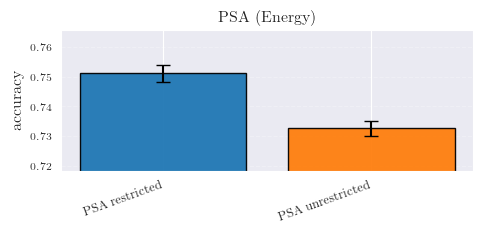


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\experiment_restrictive\resnet_small_psa_energy_summary.tex`

\begin{table}
\caption{resnet_small PSA (Energy) (mean ± SE)}
\label{tab:resnet_small_psa_energy}
\begin{tabular}{lll}
\toprule
 & PSA restricted & PSA unrestricted \\
Metric &  &  \\
\midrule
accuracy & 0.7512 ± 0.0014 & 0.7326 ± 0.0013 \\
f2\_macro & 0.7453 ± 0.0015 & 0.7256 ± 0.0013 \\
f2\_micro & 0.7512 ± 0.0014 & 0.7326 ± 0.0013 \\
f2\_weighted & 0.7475 ± 0.0014 & 0.7279 ± 0.0013 \\
\bottomrule
\end{tabular}
\end{table}



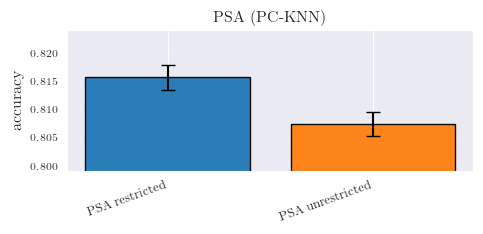


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\experiment_restrictive\resnet_small_psa_knn_summary.tex`

\begin{table}
\caption{resnet_small PSA (PC-KNN) (mean ± SE)}
\label{tab:resnet_small_psa_knn}
\begin{tabular}{lll}
\toprule
 & PSA restricted & PSA unrestricted \\
Metric &  &  \\
\midrule
accuracy & 0.8157 ± 0.0011 & 0.8074 ± 0.0011 \\
f2\_macro & 0.8128 ± 0.0011 & 0.8044 ± 0.0011 \\
f2\_micro & 0.8157 ± 0.0011 & 0.8074 ± 0.0011 \\
f2\_weighted & 0.8144 ± 0.0011 & 0.8061 ± 0.0011 \\
\bottomrule
\end{tabular}
\end{table}



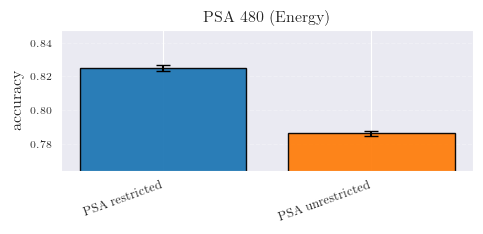


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\experiment_restrictive\resnet_small_psa_energy_480_summary.tex`

\begin{table}
\caption{resnet_small PSA 480 (Energy) (mean ± SE)}
\label{tab:resnet_small_psa_energy_480}
\begin{tabular}{lll}
\toprule
 & PSA restricted & PSA unrestricted \\
Metric &  &  \\
\midrule
accuracy & 0.8250 ± 0.0008 & 0.7863 ± 0.0007 \\
f2\_macro & 0.8208 ± 0.0008 & 0.7805 ± 0.0007 \\
f2\_micro & 0.8250 ± 0.0008 & 0.7863 ± 0.0007 \\
f2\_weighted & 0.8222 ± 0.0008 & 0.7822 ± 0.0007 \\
\bottomrule
\end{tabular}
\end{table}



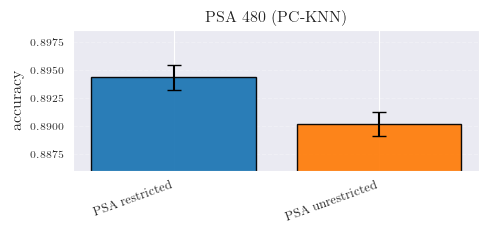


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\experiment_restrictive\resnet_small_psa_knn_480_summary.tex`

\begin{table}
\caption{resnet_small PSA 480 (PC-KNN) (mean ± SE)}
\label{tab:resnet_small_psa_knn_480}
\begin{tabular}{lll}
\toprule
 & PSA restricted & PSA unrestricted \\
Metric &  &  \\
\midrule
accuracy & 0.8943 ± 0.0006 & 0.8902 ± 0.0005 \\
f2\_macro & 0.8930 ± 0.0006 & 0.8889 ± 0.0006 \\
f2\_micro & 0.8943 ± 0.0006 & 0.8902 ± 0.0005 \\
f2\_weighted & 0.8938 ± 0.0006 & 0.8896 ± 0.0006 \\
\bottomrule
\end{tabular}
\end{table}



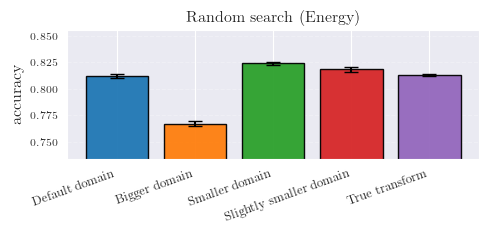


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\experiment_restrictive\resnet_small_random_energy_summary.tex`

\begin{table}
\caption{resnet_small Random search (Energy) (mean ± SE)}
\label{tab:resnet_small_random_energy}
\begin{tabular}{llllll}
\toprule
 & Default domain & Bigger domain & Smaller domain & Slightly smaller domain & True transform \\
Metric &  &  &  &  &  \\
\midrule
accuracy & 0.8122 ± 0.0011 & 0.7670 ± 0.0012 & 0.8239 ± 0.0006 & 0.8184 ± 0.0011 & 0.8129 ± 0.0006 \\
f2\_macro & 0.8079 ± 0.0011 & 0.7607 ± 0.0013 & 0.8202 ± 0.0007 & 0.8145 ± 0.0012 & 0.8086 ± 0.0006 \\
f2\_micro & 0.8122 ± 0.0011 & 0.7670 ± 0.0012 & 0.8239 ± 0.0006 & 0.8184 ± 0.0011 & 0.8129 ± 0.0006 \\
f2\_weighted & 0.8095 ± 0.0011 & 0.7626 ± 0.0013 & 0.8219 ± 0.0006 & 0.8161 ± 0.0012 & 0.8102 ± 0.0006 \\
\bottomrule
\end{tabular}
\end{table}



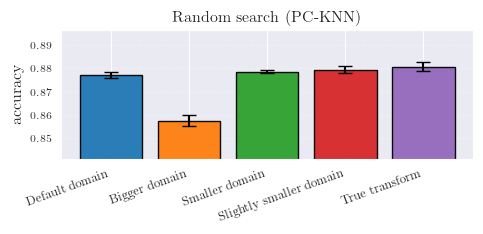


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\experiment_restrictive\resnet_small_random_knn_summary.tex`

\begin{table}
\caption{resnet_small Random search (PC-KNN) (mean ± SE)}
\label{tab:resnet_small_random_knn}
\begin{tabular}{llllll}
\toprule
 & Default domain & Bigger domain & Smaller domain & Slightly smaller domain & True transform \\
Metric &  &  &  &  &  \\
\midrule
accuracy & 0.8772 ± 0.0006 & 0.8575 ± 0.0013 & 0.8787 ± 0.0004 & 0.8795 ± 0.0007 & 0.8808 ± 0.0010 \\
f2\_macro & 0.8755 ± 0.0006 & 0.8554 ± 0.0013 & 0.8769 ± 0.0004 & 0.8778 ± 0.0008 & 0.8792 ± 0.0010 \\
f2\_micro & 0.8772 ± 0.0006 & 0.8575 ± 0.0013 & 0.8787 ± 0.0004 & 0.8795 ± 0.0007 & 0.8808 ± 0.0010 \\
f2\_weighted & 0.8766 ± 0.0006 & 0.8566 ± 0.0013 & 0.8781 ± 0.0004 & 0.8790 ± 0.0007 & 0.8803 ± 0.0010 \\
\bottomrule
\end{tabular}
\end{table}



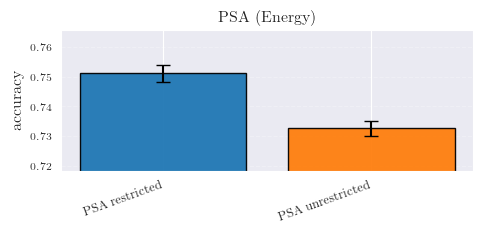


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\experiment_restrictive\resnet_small_psa_energy_summary.tex`

\begin{table}
\caption{resnet_small PSA (Energy) (mean ± SE)}
\label{tab:resnet_small_psa_energy}
\begin{tabular}{lll}
\toprule
 & PSA restricted & PSA unrestricted \\
Metric &  &  \\
\midrule
accuracy & 0.7512 ± 0.0014 & 0.7326 ± 0.0013 \\
f2\_macro & 0.7453 ± 0.0015 & 0.7256 ± 0.0013 \\
f2\_micro & 0.7512 ± 0.0014 & 0.7326 ± 0.0013 \\
f2\_weighted & 0.7475 ± 0.0014 & 0.7279 ± 0.0013 \\
\bottomrule
\end{tabular}
\end{table}



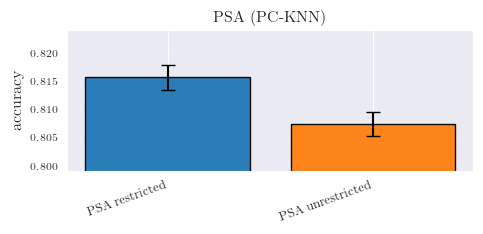


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\experiment_restrictive\resnet_small_psa_knn_summary.tex`

\begin{table}
\caption{resnet_small PSA (PC-KNN) (mean ± SE)}
\label{tab:resnet_small_psa_knn}
\begin{tabular}{lll}
\toprule
 & PSA restricted & PSA unrestricted \\
Metric &  &  \\
\midrule
accuracy & 0.8157 ± 0.0011 & 0.8074 ± 0.0011 \\
f2\_macro & 0.8128 ± 0.0011 & 0.8044 ± 0.0011 \\
f2\_micro & 0.8157 ± 0.0011 & 0.8074 ± 0.0011 \\
f2\_weighted & 0.8144 ± 0.0011 & 0.8061 ± 0.0011 \\
\bottomrule
\end{tabular}
\end{table}



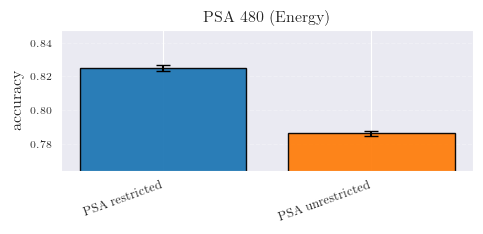


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\experiment_restrictive\resnet_small_psa_energy_480_summary.tex`

\begin{table}
\caption{resnet_small PSA 480 (Energy) (mean ± SE)}
\label{tab:resnet_small_psa_energy_480}
\begin{tabular}{lll}
\toprule
 & PSA restricted & PSA unrestricted \\
Metric &  &  \\
\midrule
accuracy & 0.8250 ± 0.0008 & 0.7863 ± 0.0007 \\
f2\_macro & 0.8208 ± 0.0008 & 0.7805 ± 0.0007 \\
f2\_micro & 0.8250 ± 0.0008 & 0.7863 ± 0.0007 \\
f2\_weighted & 0.8222 ± 0.0008 & 0.7822 ± 0.0007 \\
\bottomrule
\end{tabular}
\end{table}



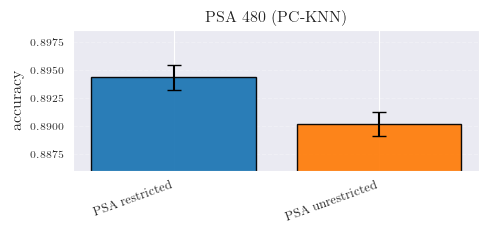


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\experiment_restrictive\resnet_small_psa_knn_480_summary.tex`

\begin{table}
\caption{resnet_small PSA 480 (PC-KNN) (mean ± SE)}
\label{tab:resnet_small_psa_knn_480}
\begin{tabular}{lll}
\toprule
 & PSA restricted & PSA unrestricted \\
Metric &  &  \\
\midrule
accuracy & 0.8943 ± 0.0006 & 0.8902 ± 0.0005 \\
f2\_macro & 0.8930 ± 0.0006 & 0.8889 ± 0.0006 \\
f2\_micro & 0.8943 ± 0.0006 & 0.8902 ± 0.0005 \\
f2\_weighted & 0.8938 ± 0.0006 & 0.8896 ± 0.0006 \\
\bottomrule
\end{tabular}
\end{table}



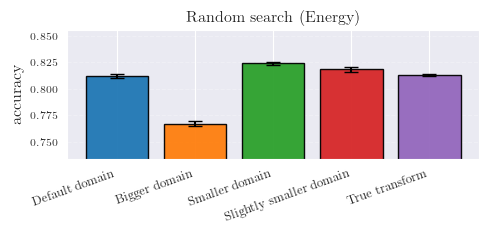


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\experiment_restrictive\resnet_small_random_energy_summary.tex`

\begin{table}
\caption{resnet_small Random search (Energy) (mean ± SE)}
\label{tab:resnet_small_random_energy}
\begin{tabular}{llllll}
\toprule
 & Default domain & Bigger domain & Smaller domain & Slightly smaller domain & True transform \\
Metric &  &  &  &  &  \\
\midrule
accuracy & 0.8122 ± 0.0011 & 0.7670 ± 0.0012 & 0.8239 ± 0.0006 & 0.8184 ± 0.0011 & 0.8129 ± 0.0006 \\
f2\_macro & 0.8079 ± 0.0011 & 0.7607 ± 0.0013 & 0.8202 ± 0.0007 & 0.8145 ± 0.0012 & 0.8086 ± 0.0006 \\
f2\_micro & 0.8122 ± 0.0011 & 0.7670 ± 0.0012 & 0.8239 ± 0.0006 & 0.8184 ± 0.0011 & 0.8129 ± 0.0006 \\
f2\_weighted & 0.8095 ± 0.0011 & 0.7626 ± 0.0013 & 0.8219 ± 0.0006 & 0.8161 ± 0.0012 & 0.8102 ± 0.0006 \\
\bottomrule
\end{tabular}
\end{table}



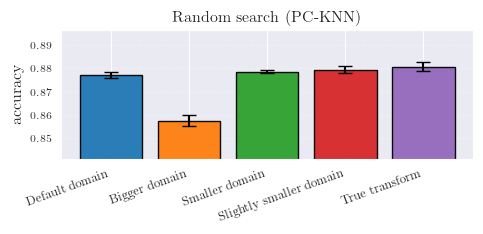


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\experiment_restrictive\resnet_small_random_knn_summary.tex`

\begin{table}
\caption{resnet_small Random search (PC-KNN) (mean ± SE)}
\label{tab:resnet_small_random_knn}
\begin{tabular}{llllll}
\toprule
 & Default domain & Bigger domain & Smaller domain & Slightly smaller domain & True transform \\
Metric &  &  &  &  &  \\
\midrule
accuracy & 0.8772 ± 0.0006 & 0.8575 ± 0.0013 & 0.8787 ± 0.0004 & 0.8795 ± 0.0007 & 0.8808 ± 0.0010 \\
f2\_macro & 0.8755 ± 0.0006 & 0.8554 ± 0.0013 & 0.8769 ± 0.0004 & 0.8778 ± 0.0008 & 0.8792 ± 0.0010 \\
f2\_micro & 0.8772 ± 0.0006 & 0.8575 ± 0.0013 & 0.8787 ± 0.0004 & 0.8795 ± 0.0007 & 0.8808 ± 0.0010 \\
f2\_weighted & 0.8766 ± 0.0006 & 0.8566 ± 0.0013 & 0.8781 ± 0.0004 & 0.8790 ± 0.0007 & 0.8803 ± 0.0010 \\
\bottomrule
\end{tabular}
\end{table}



In [49]:
from utils.eval.vis import load_json, extract_per_run_metrics, summarize_runs, choose_accuracy_metric, plot_group_short, \
    build_and_write_latex, plt_setup_latex
import os
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base_results_dir = path


# Define the four groups explicitly (only these will be plotted)
groups = [
    # PSA (Energy)
    ("psa_energy", "PSA (Energy)", [
        ("PSA restricted", f"{architecture}_restricted_domain_psa_default.json"),
        ("PSA unrestricted", f"{architecture}_unrestricted_domain_psa_default.json"),
    ]),
    # PSA (PC-KNN)
    ("psa_knn", "PSA (PC-KNN)", [
        ("PSA restricted", f"{architecture}_restricted_domain_psa_knn.json"),
        ("PSA unrestricted", f"{architecture}_unrestricted_domain_psa_knn.json"),
    ]),

    ("psa_energy_480", "PSA 480 (Energy)", [
        ("PSA restricted", f"{architecture}_restricted_domain_psa_default_480.json"),
        ("PSA unrestricted", f"{architecture}_unrestricted_domain_psa_default_480.json"),
    ]),
    # PSA (PC-KNN) 480
    ("psa_knn_480", "PSA 480 (PC-KNN)", [
        ("PSA restricted", f"{architecture}_restricted_domain_psa_knn_480.json"),
        ("PSA unrestricted", f"{architecture}_unrestricted_domain_psa_knn_480.json"),
    ]),
    # Random search (Energy)
    ("random_energy", "Random search (Energy)", [
        ("Default domain", f"{architecture}_random_search_default_domain_energy.json"),
        ("Bigger domain", f"{architecture}_bigger_domain_shgo_energy.json"),
        ("Smaller domain", f"{architecture}_smaller_domain_shgo_energy.json"),
        ("Slightly smaller domain", f"{architecture}_slighly_smaller_domain_shgo_energy.json"),
        ("True transform", f"{architecture}_true_transform_shgo_energy.json"),
    ]),
    # Random search (PC-KNN)
    ("random_knn", "Random search (PC-KNN)", [
        ("Default domain", f"{architecture}_random_search_default_domain_knn.json"),
        ("Bigger domain", f"{architecture}_bigger_domain_shgo_knn.json"),
        ("Smaller domain", f"{architecture}_smaller_domain_shgo_knn.json"),
        ("Slightly smaller domain", f"{architecture}_slighly_smaller_domain_shgo_knn.json"),
        ("True transform", f"{architecture}_true_transform_shgo_knn.json"),
    ]),
]
W = plt_setup_latex()

def process_and_plot_groups(groups, base_results_dir, architecture,save_paths=None):
    """
    Process and plot each group in `groups`.
    Each group is (group_key, group_title, items) where items is list of (label, filename).
    Files are looked up under `base_results_dir`.
    """
    counter =0
    for group_key, group_title, items in groups:
        # keep only files that exist, in the declared order
        existing = [(lbl, os.path.join(base_results_dir, fname)) for (lbl, fname) in items
                    if os.path.isfile(os.path.join(base_results_dir, fname))]

        # load and summarize
        summaries = {}
        for lbl, fpath in existing:
            obj = load_json(fpath)
            rows = extract_per_run_metrics(obj)
            mean, se = summarize_runs(rows)
            summaries[lbl] = {"mean": mean, "se": se}

        # choose plotting metric from intersection (prefer accuracy-like)
        common = None
        for s in summaries.values():
            cols = set(s["mean"].index.tolist())
            common = cols if common is None else (common & cols)
        if not common:
            print(f"[{group_key}] No common numeric metrics. Skipping plot.")
            continue
        metric = choose_accuracy_metric(sorted(common)) or sorted(common)[0]

        labels = [lbl for (lbl, _) in existing]
        means = [summaries[lbl]["mean"].get(metric, np.nan) for lbl in labels]
        ses   = [summaries[lbl]["se"].get(metric, 0.0)*1.96 for lbl in labels]
        #set default figsize
        plt.rcParams["figure.figsize"] = (W,W*0.5)

        # plot
        if save_paths is not None:
            save_path = save_paths[counter]
            plot_group_short(f"{group_title}", labels, means, ses, ylabel=metric,
                             save_path=save_path)
        else:
            plot_group_short(f"{group_title}", labels, means, ses, ylabel=metric)

        # LaTeX (full common metrics)
        build_and_write_latex(base_results_dir, architecture,
                              group_key, group_title, labels, summaries)
        counter +=1


# Example call (keeps original variables)
figure_path = os.path.join(current_path,"experiment_files","export","fig","restrictive_vs_unrestrictive")
if not os.path.exists(figure_path):
    os.makedirs(figure_path)
save_paths_pdf = [
    os.path.join(figure_path, f"{architecture}_psa_energy.pdf"),
    os.path.join(figure_path, f"{architecture}_psa_knn.pdf"),
    os.path.join(figure_path, f"{architecture}_psa_energy_480.pdf"),
    os.path.join(figure_path, f"{architecture}_psa_knn_480.pdf"),
    os.path.join(figure_path, f"{architecture}_random_energy.pdf"),
    os.path.join(figure_path, f"{architecture}_random_knn.pdf"),
]
save_paths_pgf = [
    os.path.join(figure_path, f"{architecture}_psa_energy.pgf"),
    os.path.join(figure_path, f"{architecture}_psa_knn.pgf"),
    os.path.join(figure_path, f"{architecture}_psa_energy_480.pgf"),
    os.path.join(figure_path, f"{architecture}_psa_knn_480.pgf"),
    os.path.join(figure_path, f"{architecture}_random_energy.pgf"),
    os.path.join(figure_path, f"{architecture}_random_knn.pgf"),
]
process_and_plot_groups(groups, base_results_dir, architecture, save_paths=save_paths_pdf)
process_and_plot_groups(groups, base_results_dir, architecture, save_paths=save_paths_pgf)



In [50]:
even_smaller = get_transformation_sequence_images(
                name=dataset_info.transform_seq_name,
                resample_method=dataset_info.resample_method
    ).cuda()
#decrease size of domains except first
for i in range(1,len(even_smaller.domains)):
    even_smaller.domains[i] = recursive_multiply_domains(even_smaller.domains[i], 0.65)

In [51]:

problem_knn_even_smaller= TransformationProblem(conf_mod_nn_pytorch_pretrained,even_smaller,
                                               consolidate_method="consolidate_simple")
complete_path = os.path.join(path, f"{architecture}_even_smaller_domain_shgo_knn" + ".json")
load_or_run_evaluate_confidence_and_search(model, random_search, problem_knn_even_smaller, test_loader_transformed
                                             ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)

{'repeats': 10,
 'accuracy_mean': 0.8732800483703613,
 'accuracy_std': 0.00269930437207222,
 'accuracy_se': 0.0008535949913798816,
 'f2_macro_mean': 0.8713715672492981,
 'f2_macro_std': 0.00275755999609828,
 'f2_macro_se': 0.0008720170372235593,
 'f2_micro_mean': 0.8732800483703613,
 'f2_micro_std': 0.00269930437207222,
 'f2_micro_se': 0.0008535949913798816,
 'f2_weighted_mean': 0.8727366328239441,
 'f2_weighted_std': 0.0027135706041008234,
 'f2_weighted_se': 0.0008581063700637647,
 'per_run': [{'accuracy': 0.871399998664856,
   'f2_macro': 0.8695236444473267,
   'f2_micro': 0.871399998664856,
   'f2_weighted': 0.8708627223968506,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.8748000264167786,
   'f2_macro': 0.8728104829788208,
   'f2_micro': 0.8748000264167786,
   'f2_weighted': 0.8742699027061462,
   'per_sample_errors': None,
   'per_sample_matrices'

In [52]:
#test wether to use sobol sampling or not
transform_seq_sobol = get_transformation_sequence_images(
                name=dataset_info.transform_seq_name,
                resample_method=dataset_info.resample_method,
    init_method="sobol"
    ).cuda()
transform_seq_individual = get_transformation_sequence_images(
                name=dataset_info.transform_seq_name,
                resample_method=dataset_info.resample_method,
    init_method="individual"
    ).cuda()

transform_seq_latin_hypercube = get_transformation_sequence_images(
                name=dataset_info.transform_seq_name,
                resample_method=dataset_info.resample_method,
    init_method="latin_hypercube"
    ).cuda()

transform_seq_permuted_lattice = get_transformation_sequence_images(
                name=dataset_info.transform_seq_name,
                resample_method=dataset_info.resample_method,
    init_method="permuted_lattice"
    ).cuda()

In [53]:
#compare them
problem_knn_sobol= TransformationProblem(conf_mod_nn_pytorch_pretrained,transform_seq_sobol,
                                               consolidate_method="consolidate_simple")
complete_path = os.path.join(path, f"{architecture}_sobol_sampling_shgo_knn" + ".json")

load_or_run_evaluate_confidence_and_search(model, random_search, problem_knn_sobol, test_loader_transformed
                                             ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)



{'repeats': 10,
 'accuracy_mean': 0.8876700401306152,
 'accuracy_std': 0.0021018816623836756,
 'accuracy_se': 0.0006646733425273473,
 'f2_macro_mean': 0.8861585855484009,
 'f2_macro_std': 0.0021210485137999058,
 'f2_macro_se': 0.0006707344331322784,
 'f2_micro_mean': 0.8876700401306152,
 'f2_micro_std': 0.0021018816623836756,
 'f2_micro_se': 0.0006646733425273473,
 'f2_weighted_mean': 0.8871981501579285,
 'f2_weighted_std': 0.002105667721480131,
 'f2_weighted_se': 0.0006658705995374271,
 'per_run': [{'accuracy': 0.886900007724762,
   'f2_macro': 0.8852940797805786,
   'f2_micro': 0.886900007724762,
   'f2_weighted': 0.8863840103149414,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.891700029373169,
   'f2_macro': 0.8902968168258667,
   'f2_micro': 0.891700029373169,
   'f2_weighted': 0.8912802934646606,
   'per_sample_errors': None,
   'per_sample_matric

In [54]:
problem_knn_individual= TransformationProblem(conf_mod_nn_pytorch_pretrained,transform_seq_individual,
                                               consolidate_method="consolidate_simple")
complete_path = os.path.join(path, f"{architecture}_individual_sampling_shgo_knn" + ".json")
load_or_run_evaluate_confidence_and_search(model, random_search, problem_knn_individual, test_loader_transformed
                                             ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)


{'repeats': 10,
 'accuracy_mean': 0.8771399259567261,
 'accuracy_std': 0.0015636134194210172,
 'accuracy_se': 0.0004944579785374572,
 'f2_macro_mean': 0.8754671216011047,
 'f2_macro_std': 0.0015535556012764573,
 'f2_macro_se': 0.0004912774171745995,
 'f2_micro_mean': 0.8771399259567261,
 'f2_micro_std': 0.0015636134194210172,
 'f2_micro_se': 0.0004944579785374572,
 'f2_weighted_mean': 0.8765758275985718,
 'f2_weighted_std': 0.001564206089824438,
 'f2_weighted_se': 0.0004946453973751154,
 'per_run': [{'accuracy': 0.8794000148773193,
   'f2_macro': 0.8776750564575195,
   'f2_micro': 0.8794000148773193,
   'f2_weighted': 0.8788979053497314,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.8755000233650208,
   'f2_macro': 0.8737833499908447,
   'f2_micro': 0.8755000233650208,
   'f2_weighted': 0.8749441504478455,
   'per_sample_errors': None,
   'per_sample_ma

In [55]:
problem_knn_latin_hypercube= TransformationProblem(conf_mod_nn_pytorch_pretrained,transform_seq_latin_hypercube,
                                               consolidate_method="consolidate_simple")
complete_path = os.path.join(path, f"{architecture}_latin_hypercube_sampling_shgo_knn" + ".json")
load_or_run_evaluate_confidence_and_search(model, random_search, problem_knn_latin_hypercube, test_loader_transformed
                                             ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)

{'repeats': 10,
 'accuracy_mean': 0.8803799748420715,
 'accuracy_std': 0.001392694073729217,
 'accuracy_se': 0.00044040853568027964,
 'f2_macro_mean': 0.8787163496017456,
 'f2_macro_std': 0.0014548322651535273,
 'f2_macro_se': 0.0004600583571387159,
 'f2_micro_mean': 0.8803799748420715,
 'f2_micro_std': 0.001392694073729217,
 'f2_micro_se': 0.00044040853568027964,
 'f2_weighted_mean': 0.8798545598983765,
 'f2_weighted_std': 0.0013965860707685351,
 'f2_weighted_se': 0.00044163929320936734,
 'per_run': [{'accuracy': 0.8776999711990356,
   'f2_macro': 0.8759275078773499,
   'f2_micro': 0.8776999711990356,
   'f2_weighted': 0.8772408366203308,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.881600022315979,
   'f2_macro': 0.8798388242721558,
   'f2_micro': 0.881600022315979,
   'f2_weighted': 0.8810986876487732,
   'per_sample_errors': None,
   'per_sample_ma

In [56]:
problem_knn_permuted_lattice= TransformationProblem(conf_mod_nn_pytorch_pretrained,transform_seq_permuted_lattice,
                                               consolidate_method="consolidate_simple")
complete_path = os.path.join(path, f"{architecture}_permuted_lattice_sampling_shgo_knn" + ".json")
load_or_run_evaluate_confidence_and_search(model, random_search, problem_knn_permuted_lattice, test_loader_transformed
                                             ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)

{'repeats': 10,
 'accuracy_mean': 0.882099986076355,
 'accuracy_std': 0.002187844133004546,
 'accuracy_se': 0.0006918570625730733,
 'f2_macro_mean': 0.8804776072502136,
 'f2_macro_std': 0.0022202045656740665,
 'f2_macro_se': 0.000702090329903494,
 'f2_micro_mean': 0.882099986076355,
 'f2_micro_std': 0.002187844133004546,
 'f2_micro_se': 0.0006918570625730733,
 'f2_weighted_mean': 0.8815613985061646,
 'f2_weighted_std': 0.002196645364165306,
 'f2_weighted_se': 0.0006946402562412381,
 'per_run': [{'accuracy': 0.8831999897956848,
   'f2_macro': 0.8816203474998474,
   'f2_micro': 0.8831999897956848,
   'f2_weighted': 0.8826740384101868,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.879800021648407,
   'f2_macro': 0.8781929016113281,
   'f2_micro': 0.879800021648407,
   'f2_weighted': 0.8792677521705627,
   'per_sample_errors': None,
   'per_sample_matrices'

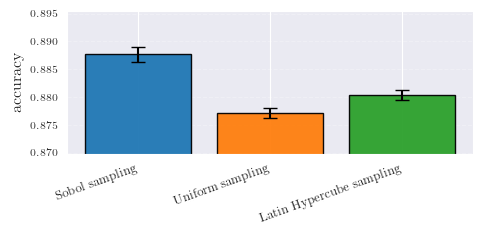


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\experiment_restrictive\resnet_small_random_knn_sampling_summary.tex`

\begin{table}
\caption{resnet_small  (mean ± SE)}
\label{tab:resnet_small_random_knn_sampling}
\begin{tabular}{llll}
\toprule
 & Sobol sampling & Uniform sampling & Latin Hypercube sampling \\
Metric &  &  &  \\
\midrule
accuracy & 0.8877 ± 0.0007 & 0.8771 ± 0.0005 & 0.8804 ± 0.0004 \\
f2\_macro & 0.8862 ± 0.0007 & 0.8755 ± 0.0005 & 0.8787 ± 0.0005 \\
f2\_micro & 0.8877 ± 0.0007 & 0.8771 ± 0.0005 & 0.8804 ± 0.0004 \\
f2\_weighted & 0.8872 ± 0.0007 & 0.8766 ± 0.0005 & 0.8799 ± 0.0004 \\
\bottomrule
\end{tabular}
\end{table}



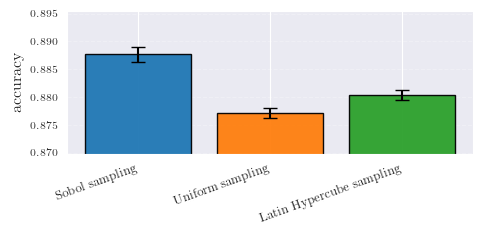


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\experiment_restrictive\resnet_small_random_knn_sampling_summary.tex`

\begin{table}
\caption{resnet_small  (mean ± SE)}
\label{tab:resnet_small_random_knn_sampling}
\begin{tabular}{llll}
\toprule
 & Sobol sampling & Uniform sampling & Latin Hypercube sampling \\
Metric &  &  &  \\
\midrule
accuracy & 0.8877 ± 0.0007 & 0.8771 ± 0.0005 & 0.8804 ± 0.0004 \\
f2\_macro & 0.8862 ± 0.0007 & 0.8755 ± 0.0005 & 0.8787 ± 0.0005 \\
f2\_micro & 0.8877 ± 0.0007 & 0.8771 ± 0.0005 & 0.8804 ± 0.0004 \\
f2\_weighted & 0.8872 ± 0.0007 & 0.8766 ± 0.0005 & 0.8799 ± 0.0004 \\
\bottomrule
\end{tabular}
\end{table}



In [97]:
groups_new = [
    # Random search (PC-KNN) with different samplings
    ("random_knn_sampling", "", [
        ("Sobol sampling", f"{architecture}_sobol_sampling_shgo_knn.json"),
        ("Uniform sampling", f"{architecture}_individual_sampling_shgo_knn.json"),
        ("Latin Hypercube sampling", f"{architecture}_latin_hypercube_sampling_shgo_knn.json"),
    ]),
]
save_paths_new_pdf = [
    os.path.join(figure_path, f"{architecture}_random_knn_sampling.pdf"),
]
save_paths_new_pgf = [
    os.path.join(figure_path, f"{architecture}_random_knn_sampling.pgf"),
]
process_and_plot_groups(groups_new, base_results_dir, architecture, save_paths=save_paths_new_pdf)
process_and_plot_groups(groups_new, base_results_dir, architecture, save_paths=save_paths_new_pgf)

In [58]:
cd = WeightedCoordinateDescent(samples_per_dim=[12,3,3,3,3],rounds=2)

In [59]:
#compare them
print("Starting sobol sampling for cd")
problem_knn_sobol= TransformationProblem(conf_mod_nn_pytorch_pretrained,transform_seq_sobol,
                                               consolidate_method="consolidate_simple")
complete_path = os.path.join(path, f"{architecture}_cd_sobol_sampling_shgo_knn" + ".json")

load_or_run_evaluate_confidence_and_search(model, cd, problem_knn_sobol, test_loader_transformed
                                             ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)



Starting sobol sampling for cd



{'repeats': 10,
 'accuracy_mean': 0.7731600403785706,
 'accuracy_std': 0.0039710612036287785,
 'accuracy_se': 0.001255759813139664,
 'f2_macro_mean': 0.7690454721450806,
 'f2_macro_std': 0.004021827597171068,
 'f2_macro_se': 0.001271813556358274,
 'f2_micro_mean': 0.7731600403785706,
 'f2_micro_std': 0.0039710612036287785,
 'f2_micro_se': 0.001255759813139664,
 'f2_weighted_mean': 0.7716161012649536,
 'f2_weighted_std': 0.004029856063425541,
 'f2_weighted_se': 0.0012743523803064674,
 'per_run': [{'accuracy': 0.779699981212616,
   'f2_macro': 0.7757240533828735,
   'f2_micro': 0.779699981212616,
   'f2_weighted': 0.7782968282699585,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.7781999707221985,
   'f2_macro': 0.7740477323532104,
   'f2_micro': 0.7781999707221985,
   'f2_weighted': 0.7766884565353394,
   'per_sample_errors': None,
   'per_sample_matrices

In [60]:
print("Starting individual sampling for cd")
problem_knn_individual= TransformationProblem(conf_mod_nn_pytorch_pretrained,transform_seq_individual,
                                               consolidate_method="consolidate_simple")
complete_path = os.path.join(path, f"{architecture}_cd_individual_sampling_shgo_knn" + ".json")
load_or_run_evaluate_confidence_and_search(model, cd, problem_knn_individual, test_loader_transformed
                                             ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)


Starting individual sampling for cd



{'repeats': 10,
 'accuracy_mean': 0.768060028553009,
 'accuracy_std': 0.0019889597315341234,
 'accuracy_se': 0.0006289642926004855,
 'f2_macro_mean': 0.7638537287712097,
 'f2_macro_std': 0.002066848799586296,
 'f2_macro_se': 0.0006535949785877576,
 'f2_micro_mean': 0.768060028553009,
 'f2_micro_std': 0.0019889597315341234,
 'f2_micro_se': 0.0006289642926004855,
 'f2_weighted_mean': 0.7664037346839905,
 'f2_weighted_std': 0.002020564628764987,
 'f2_weighted_se': 0.0006389586386469933,
 'per_run': [{'accuracy': 0.7692999839782715,
   'f2_macro': 0.7652141451835632,
   'f2_micro': 0.7692999839782715,
   'f2_weighted': 0.7677420377731323,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.766700029373169,
   'f2_macro': 0.7622554302215576,
   'f2_micro': 0.766700029373169,
   'f2_weighted': 0.7648826837539673,
   'per_sample_errors': None,
   'per_sample_matrice

In [61]:
print("Starting latin hypercube sampling for cd")
problem_knn_latin_hypercube= TransformationProblem(conf_mod_nn_pytorch_pretrained,transform_seq_latin_hypercube,
                                               consolidate_method="consolidate_simple")
complete_path = os.path.join(path, f"{architecture}_cd_latin_hypercube_sampling_shgo_knn" + ".json")
load_or_run_evaluate_confidence_and_search(model, cd, problem_knn_latin_hypercube, test_loader_transformed
                                             ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)

Starting latin hypercube sampling for cd



{'repeats': 10,
 'accuracy_mean': 0.7871500253677368,
 'accuracy_std': 0.0024967659264802933,
 'accuracy_se': 0.0007895467111978237,
 'f2_macro_mean': 0.783275306224823,
 'f2_macro_std': 0.0025500075425952673,
 'f2_macro_se': 0.000806383188520988,
 'f2_micro_mean': 0.7871500253677368,
 'f2_micro_std': 0.0024967659264802933,
 'f2_micro_se': 0.0007895467111978237,
 'f2_weighted_mean': 0.7856565713882446,
 'f2_weighted_std': 0.0025409834925085306,
 'f2_weighted_se': 0.0008035295333216352,
 'per_run': [{'accuracy': 0.784600019454956,
   'f2_macro': 0.7805995941162109,
   'f2_micro': 0.784600019454956,
   'f2_weighted': 0.7829602956771851,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.7860000133514404,
   'f2_macro': 0.782019853591919,
   'f2_micro': 0.7860000133514404,
   'f2_weighted': 0.784480094909668,
   'per_sample_errors': None,
   'per_sample_matrice

In [62]:
print("Starting permuted lattice sampling for cd")
problem_knn_permuted_lattice= TransformationProblem(conf_mod_nn_pytorch_pretrained,transform_seq_permuted_lattice,
                                               consolidate_method="consolidate_simple")
complete_path = os.path.join(path, f"{architecture}_cd_permuted_lattice_sampling_shgo_knn" + ".json")
load_or_run_evaluate_confidence_and_search(model, cd, problem_knn_permuted_lattice, test_loader_transformed
                                             ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)

Starting permuted lattice sampling for cd



{'repeats': 10,
 'accuracy_mean': 0.7878900170326233,
 'accuracy_std': 0.0019052179995924234,
 'accuracy_se': 0.0006024828317861808,
 'f2_macro_mean': 0.7839195132255554,
 'f2_macro_std': 0.0019945583771914244,
 'f2_macro_se': 0.0006307347398094137,
 'f2_micro_mean': 0.7878900170326233,
 'f2_micro_std': 0.0019052179995924234,
 'f2_micro_se': 0.0006024828317861808,
 'f2_weighted_mean': 0.7863499522209167,
 'f2_weighted_std': 0.001965598203241825,
 'f2_weighted_se': 0.0006215767286978729,
 'per_run': [{'accuracy': 0.7896999716758728,
   'f2_macro': 0.7858024835586548,
   'f2_micro': 0.7896999716758728,
   'f2_weighted': 0.7881981134414673,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.7860999703407288,
   'f2_macro': 0.7820327281951904,
   'f2_micro': 0.7860999703407288,
   'f2_weighted': 0.78458172082901,
   'per_sample_errors': None,
   'per_sample_matr

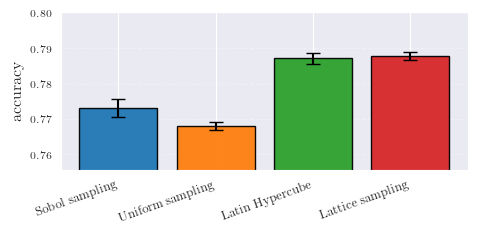


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\experiment_restrictive\resnet_small_cd_knn_sampling_summary.tex`

\begin{table}
\caption{resnet_small  (mean ± SE)}
\label{tab:resnet_small_cd_knn_sampling}
\begin{tabular}{lllll}
\toprule
 & Sobol sampling & Uniform sampling & Latin Hypercube & Lattice sampling \\
Metric &  &  &  &  \\
\midrule
accuracy & 0.7732 ± 0.0013 & 0.7681 ± 0.0006 & 0.7872 ± 0.0008 & 0.7879 ± 0.0006 \\
f2\_macro & 0.7690 ± 0.0013 & 0.7639 ± 0.0007 & 0.7833 ± 0.0008 & 0.7839 ± 0.0006 \\
f2\_micro & 0.7732 ± 0.0013 & 0.7681 ± 0.0006 & 0.7872 ± 0.0008 & 0.7879 ± 0.0006 \\
f2\_weighted & 0.7716 ± 0.0013 & 0.7664 ± 0.0006 & 0.7857 ± 0.0008 & 0.7863 ± 0.0006 \\
\bottomrule
\end{tabular}
\end{table}



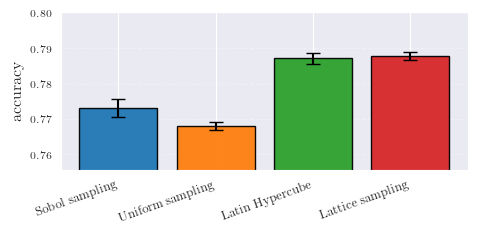


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\experiment_restrictive\resnet_small_cd_knn_sampling_summary.tex`

\begin{table}
\caption{resnet_small  (mean ± SE)}
\label{tab:resnet_small_cd_knn_sampling}
\begin{tabular}{lllll}
\toprule
 & Sobol sampling & Uniform sampling & Latin Hypercube & Lattice sampling \\
Metric &  &  &  &  \\
\midrule
accuracy & 0.7732 ± 0.0013 & 0.7681 ± 0.0006 & 0.7872 ± 0.0008 & 0.7879 ± 0.0006 \\
f2\_macro & 0.7690 ± 0.0013 & 0.7639 ± 0.0007 & 0.7833 ± 0.0008 & 0.7839 ± 0.0006 \\
f2\_micro & 0.7732 ± 0.0013 & 0.7681 ± 0.0006 & 0.7872 ± 0.0008 & 0.7879 ± 0.0006 \\
f2\_weighted & 0.7716 ± 0.0013 & 0.7664 ± 0.0006 & 0.7857 ± 0.0008 & 0.7863 ± 0.0006 \\
\bottomrule
\end{tabular}
\end{table}



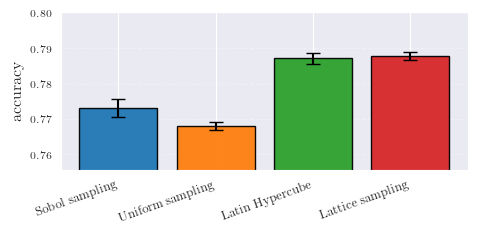


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\experiment_restrictive\resnet_small_cd_knn_sampling_summary.tex`

\begin{table}
\caption{resnet_small  (mean ± SE)}
\label{tab:resnet_small_cd_knn_sampling}
\begin{tabular}{lllll}
\toprule
 & Sobol sampling & Uniform sampling & Latin Hypercube & Lattice sampling \\
Metric &  &  &  &  \\
\midrule
accuracy & 0.7732 ± 0.0013 & 0.7681 ± 0.0006 & 0.7872 ± 0.0008 & 0.7879 ± 0.0006 \\
f2\_macro & 0.7690 ± 0.0013 & 0.7639 ± 0.0007 & 0.7833 ± 0.0008 & 0.7839 ± 0.0006 \\
f2\_micro & 0.7732 ± 0.0013 & 0.7681 ± 0.0006 & 0.7872 ± 0.0008 & 0.7879 ± 0.0006 \\
f2\_weighted & 0.7716 ± 0.0013 & 0.7664 ± 0.0006 & 0.7857 ± 0.0008 & 0.7863 ± 0.0006 \\
\bottomrule
\end{tabular}
\end{table}



In [96]:
#plot the results of cd
groups_cd = [
    # Coordinate Descent (PC-KNN) with different samplings
    ("cd_knn_sampling", "", [
        ("Sobol sampling", f"{architecture}_cd_sobol_sampling_shgo_knn.json"),
        ("Uniform sampling", f"{architecture}_cd_individual_sampling_shgo_knn.json"),
        ("Latin Hypercube", f"{architecture}_cd_latin_hypercube_sampling_shgo_knn.json"),
        ("Lattice sampling", f"{architecture}_cd_permuted_lattice_sampling_shgo_knn.json"),
    ]),
]
save_paths_cd_pdf = [
    os.path.join(figure_path, f"{architecture}_cd_knn_sampling.pdf"),
]
save_paths_cd_pgf = [
    os.path.join(figure_path, f"{architecture}_cd_knn_sampling.pgf"),
]
process_and_plot_groups(groups_cd, base_results_dir, architecture, save_paths=save_paths_cd_pdf)
process_and_plot_groups(groups_cd, base_results_dir, architecture, save_paths=save_paths_cd_pgf)
process_and_plot_groups(groups_cd, base_results_dir, architecture)


In [64]:
random_search_no_amp = SHGO(initial_samples=46, local_runs=2, local_max_steps=3,project_param=False)
random_search_amp = random_search_no_amp
print()
complete_path = os.path.join(path, f"{architecture}_random_search_default_domain_amp_knn" + ".json")
with torch.amp.autocast('cuda'):
    load_or_run_evaluate_confidence_and_search(model, random_search_amp, problem_knn, test_loader_transformed
                                                 ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)

In [65]:
print()
complete_path = os.path.join(path, f"{architecture}_random_search_default_domain_amp_energy" + ".json")
with torch.amp.autocast('cuda'):
    load_or_run_evaluate_confidence_and_search(model, random_search_amp, problem_energy, test_loader_transformed
                                                 ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)

In [66]:
#combare results of random search default without autocast and with amp


complete_path = os.path.join(path, f"{architecture}_random_search_default_domain_no_amp_knn" + ".json")
print()
load_or_run_evaluate_confidence_and_search(model, random_search_no_amp, problem_knn, test_loader_transformed
                                             ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)

{'repeats': 10,
 'accuracy_mean': 0.8423299789428711,
 'accuracy_std': 0.002902120817452669,
 'accuracy_se': 0.000917731182814017,
 'f2_macro_mean': 0.8398949503898621,
 'f2_macro_std': 0.002986422972753644,
 'f2_macro_se': 0.0009443898650552488,
 'f2_micro_mean': 0.8423299789428711,
 'f2_micro_std': 0.002902120817452669,
 'f2_micro_se': 0.000917731182814017,
 'f2_weighted_mean': 0.8413796424865723,
 'f2_weighted_std': 0.0029192082583904266,
 'f2_weighted_se': 0.0009231347060887087,
 'per_run': [{'accuracy': 0.8445000052452087,
   'f2_macro': 0.8422175049781799,
   'f2_micro': 0.8445000052452087,
   'f2_weighted': 0.8436151742935181,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.8410000205039978,
   'f2_macro': 0.8385177850723267,
   'f2_micro': 0.8410000205039978,
   'f2_weighted': 0.8400260806083679,
   'per_sample_errors': None,
   'per_sample_matric

In [67]:

complete_path = os.path.join(path, f"{architecture}_random_search_default_domain_no_amp_energy" + ".json")
load_or_run_evaluate_confidence_and_search(model, random_search_no_amp, problem_energy, test_loader_transformed
                                             ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)


{'repeats': 10,
 'accuracy_mean': 0.7844300866127014,
 'accuracy_std': 0.0035455822944641113,
 'accuracy_se': 0.0011212115682072404,
 'f2_macro_mean': 0.7796070575714111,
 'f2_macro_std': 0.0035974245984107256,
 'f2_macro_se': 0.001137605544169444,
 'f2_micro_mean': 0.7844300866127014,
 'f2_micro_std': 0.0035455822944641113,
 'f2_micro_se': 0.0011212115682072404,
 'f2_weighted_mean': 0.781443178653717,
 'f2_weighted_std': 0.003603976685553789,
 'f2_weighted_se': 0.0011396774960494426,
 'per_run': [{'accuracy': 0.7875999808311462,
   'f2_macro': 0.7827970385551453,
   'f2_micro': 0.7875999808311462,
   'f2_weighted': 0.7845857739448547,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.7771000266075134,
   'f2_macro': 0.7722135782241821,
   'f2_micro': 0.7771000266075134,
   'f2_weighted': 0.7739083766937256,
   'per_sample_errors': None,
   'per_sample_matr

In [68]:
class autocastmodelwrapper(torch.nn.Module):
    def __init__(self,model):
        super(autocastmodelwrapper, self).__init__()
        self.model = model
    def forward(self,x):
        with torch.amp.autocast('cuda'):
            return self.model(x)
dual_output_model_ac = cache_train.make_wrapper("fc",capture_modes='input',concat=False,flatten=True)
dual_output_model_ac = autocastmodelwrapper(dual_output_model_ac)
knn_conf_amp_forward_only= SinglePassConfidence(dual_output_model_ac,conf_split_pretrained,index=1)
problem_knn_amp= TransformationProblem(knn_conf_amp_forward_only,transform_seq,consolidate_method="consolidate_simple")





In [69]:
complete_path = os.path.join(path, f"{architecture}_random_search_default_domain_amp_forward_only_knn" + ".json")

load_or_run_evaluate_confidence_and_search(model, random_search_amp, problem_knn_amp, test_loader_transformed
                                             ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)



{'repeats': 10,
 'accuracy_mean': 0.8392400741577148,
 'accuracy_std': 0.0028111697174608707,
 'accuracy_se': 0.0008889699196468366,
 'f2_macro_mean': 0.8367688059806824,
 'f2_macro_std': 0.002899280982092023,
 'f2_macro_se': 0.0009168331480220643,
 'f2_micro_mean': 0.8392400741577148,
 'f2_micro_std': 0.0028111697174608707,
 'f2_micro_se': 0.0008889699196468366,
 'f2_weighted_mean': 0.8382506370544434,
 'f2_weighted_std': 0.0028235723730176687,
 'f2_weighted_se': 0.0008928919837062391,
 'per_run': [{'accuracy': 0.8403000235557556,
   'f2_macro': 0.8376567959785461,
   'f2_micro': 0.8403000235557556,
   'f2_weighted': 0.8392500877380371,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.8428999781608582,
   'f2_macro': 0.8406564593315125,
   'f2_micro': 0.8428999781608582,
   'f2_weighted': 0.8420376777648926,
   'per_sample_errors': None,
   'per_sample_ma

In [70]:
energy_conf_amp_forward_only= SinglePassConfidence(autocastmodelwrapper(model),EnergyConfidence())
problem_energy_amp= TransformationProblem(energy_conf_amp_forward_only,transform_seq,consolidate_method="consolidate_simple")


In [71]:
complete_path = os.path.join(path, f"{architecture}_random_search_default_domain_amp_forward_only_energy" + ".json")
load_or_run_evaluate_confidence_and_search(model, random_search_amp, problem_energy_amp, test_loader_transformed
                                             ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)

{'repeats': 10,
 'accuracy_mean': 0.7849400639533997,
 'accuracy_std': 0.0037612670566886663,
 'accuracy_se': 0.0011894170787293842,
 'f2_macro_mean': 0.7802435159683228,
 'f2_macro_std': 0.0038770942483097315,
 'f2_macro_se': 0.0012260448527797179,
 'f2_micro_mean': 0.7849400639533997,
 'f2_micro_std': 0.0037612670566886663,
 'f2_micro_se': 0.0011894170787293842,
 'f2_weighted_mean': 0.7821338772773743,
 'f2_weighted_std': 0.003906070254743099,
 'f2_weighted_se': 0.0012352078705622313,
 'per_run': [{'accuracy': 0.789900004863739,
   'f2_macro': 0.7852215766906738,
   'f2_micro': 0.789900004863739,
   'f2_weighted': 0.7873146533966064,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.7838000059127808,
   'f2_macro': 0.7792795896530151,
   'f2_micro': 0.7838000059127808,
   'f2_weighted': 0.7810503244400024,
   'per_sample_errors': None,
   'per_sample_matr

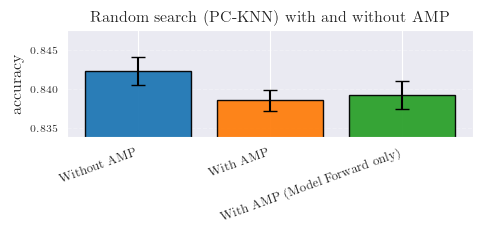


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\experiment_restrictive\resnet_small_random_knn_amp_summary.tex`

\begin{table}
\caption{resnet_small Random search (PC-KNN) with and without AMP (mean ± SE)}
\label{tab:resnet_small_random_knn_amp}
\begin{tabular}{llll}
\toprule
 & Without AMP & With AMP & With AMP (Model Forward only) \\
Metric &  &  &  \\
\midrule
accuracy & 0.8423 ± 0.0009 & 0.8385 ± 0.0007 & 0.8392 ± 0.0009 \\
f2\_macro & 0.8399 ± 0.0009 & 0.8361 ± 0.0007 & 0.8368 ± 0.0009 \\
f2\_micro & 0.8423 ± 0.0009 & 0.8385 ± 0.0007 & 0.8392 ± 0.0009 \\
f2\_weighted & 0.8414 ± 0.0009 & 0.8376 ± 0.0007 & 0.8383 ± 0.0009 \\
\bottomrule
\end{tabular}
\end{table}



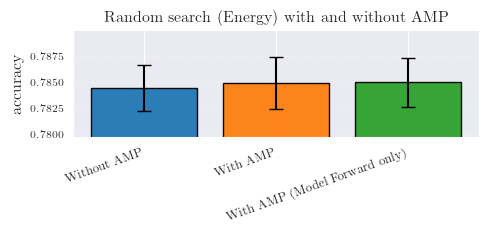


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\experiment_restrictive\resnet_small_random_energy_amp_summary.tex`

\begin{table}
\caption{resnet_small Random search (Energy) with and without AMP (mean ± SE)}
\label{tab:resnet_small_random_energy_amp}
\begin{tabular}{llll}
\toprule
 & Without AMP & With AMP & With AMP (Model Forward only) \\
Metric &  &  &  \\
\midrule
accuracy & 0.7844 ± 0.0011 & 0.7849 ± 0.0013 & 0.7849 ± 0.0012 \\
f2\_macro & 0.7796 ± 0.0011 & 0.7802 ± 0.0013 & 0.7802 ± 0.0012 \\
f2\_micro & 0.7844 ± 0.0011 & 0.7849 ± 0.0013 & 0.7849 ± 0.0012 \\
f2\_weighted & 0.7814 ± 0.0011 & 0.7821 ± 0.0013 & 0.7821 ± 0.0012 \\
\bottomrule
\end{tabular}
\end{table}



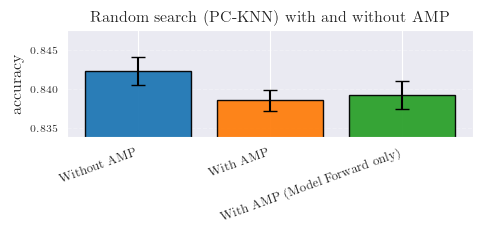


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\experiment_restrictive\resnet_small_random_knn_amp_summary.tex`

\begin{table}
\caption{resnet_small Random search (PC-KNN) with and without AMP (mean ± SE)}
\label{tab:resnet_small_random_knn_amp}
\begin{tabular}{llll}
\toprule
 & Without AMP & With AMP & With AMP (Model Forward only) \\
Metric &  &  &  \\
\midrule
accuracy & 0.8423 ± 0.0009 & 0.8385 ± 0.0007 & 0.8392 ± 0.0009 \\
f2\_macro & 0.8399 ± 0.0009 & 0.8361 ± 0.0007 & 0.8368 ± 0.0009 \\
f2\_micro & 0.8423 ± 0.0009 & 0.8385 ± 0.0007 & 0.8392 ± 0.0009 \\
f2\_weighted & 0.8414 ± 0.0009 & 0.8376 ± 0.0007 & 0.8383 ± 0.0009 \\
\bottomrule
\end{tabular}
\end{table}



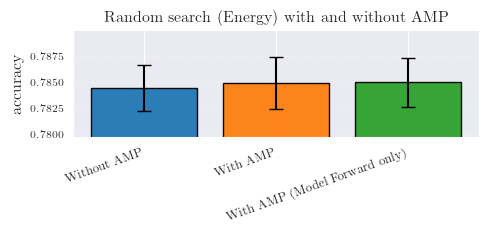


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\experiment_restrictive\resnet_small_random_energy_amp_summary.tex`

\begin{table}
\caption{resnet_small Random search (Energy) with and without AMP (mean ± SE)}
\label{tab:resnet_small_random_energy_amp}
\begin{tabular}{llll}
\toprule
 & Without AMP & With AMP & With AMP (Model Forward only) \\
Metric &  &  &  \\
\midrule
accuracy & 0.7844 ± 0.0011 & 0.7849 ± 0.0013 & 0.7849 ± 0.0012 \\
f2\_macro & 0.7796 ± 0.0011 & 0.7802 ± 0.0013 & 0.7802 ± 0.0012 \\
f2\_micro & 0.7844 ± 0.0011 & 0.7849 ± 0.0013 & 0.7849 ± 0.0012 \\
f2\_weighted & 0.7814 ± 0.0011 & 0.7821 ± 0.0013 & 0.7821 ± 0.0012 \\
\bottomrule
\end{tabular}
\end{table}



In [72]:
#plot the results
groups_amp = [
    # Random search (PC-KNN) with and without AMP
    ("random_knn_amp", "Random search (PC-KNN) with and without AMP", [
        ("Without AMP", f"{architecture}_random_search_default_domain_no_amp_knn.json"),
        ("With AMP", f"{architecture}_random_search_default_domain_amp_knn.json"),
        ("With AMP (Model Forward only)", f"{architecture}_random_search_default_domain_amp_forward_only_knn.json"),
    ]),
    # Random search (Energy) with and without AMP
    ("random_energy_amp", "Random search (Energy) with and without AMP", [
        ("Without AMP", f"{architecture}_random_search_default_domain_no_amp_energy.json"),
        ("With AMP", f"{architecture}_random_search_default_domain_amp_energy.json"),
        ("With AMP (Model Forward only)", f"{architecture}_random_search_default_domain_amp_forward_only_energy.json"),
    ]),
]
save_paths_amp_pdf = [
    os.path.join(figure_path, f"{architecture}_random_knn_amp.pdf"),
    os.path.join(figure_path, f"{architecture}_random_energy_amp.pdf"),
    os.path.join(figure_path, f"{architecture}_random_energy_amp_forward_only.pdf"),
]
save_paths_amp_pgf = [
    os.path.join(figure_path, f"{architecture}_random_knn_amp.pgf"),
    os.path.join(figure_path, f"{architecture}_random_energy_amp.pgf"),
    os.path.join(figure_path, f"{architecture}_random_energy_amp_forward_only.pgf"),
]
process_and_plot_groups(groups_amp, base_results_dir, architecture, save_paths=save_paths_amp_pdf)
process_and_plot_groups(groups_amp, base_results_dir, architecture, save_paths=save_paths_amp_pgf)

In [73]:
#print dtype of previos knn
print("Dtype of previous knn:",nn_pytorch_pretrained.dtype)

Dtype of previous knn: torch.float16


In [74]:
#tesst wether knn with float 32 improves results
nn_pytorch_pretrained_fp32= PerClassKNNConfidence(metric="cosine",input_transform=None,dtype=torch.float32)
nn_pytorch_pretrained_fp32.fit(embeddings_t,classes_t)
nn_pytorch_pretrained_fp32.cuda()

conf_split_pretrained_fp32 = PredictedSplitConfidence(nn_pytorch_pretrained_fp32,EnergyConfidence(), mult=False,b=0.0)
conf_mod_nn_pytorch_pretrained_fp32 = SinglePassConfidence(dual_output_model,conf_split_pretrained_fp32,index=1)
problem_nn_pytorch_pretrained_fp32 = TransformationProblem(conf_mod_nn_pytorch_pretrained_fp32,transform_seq,consolidate_method="consolidate_simple")

In [75]:
print("Dtype of knn with float32:",nn_pytorch_pretrained_fp32.dtype)

Dtype of knn with float32: torch.float32


In [76]:
#test it
complete_path = os.path.join(path, f"{architecture}_random_search_default_domain_fp32_knn" + ".json")
load_or_run_evaluate_confidence_and_search(model, random_search, problem_nn_pytorch_pretrained_fp32, test_loader_transformed
                                             ,max_batch_override=1280,repeats=repeats,save_path=complete_path,overwrite=overwrite)


{'repeats': 10,
 'accuracy_mean': 0.877769947052002,
 'accuracy_std': 0.002134921494871378,
 'accuracy_se': 0.0006751214549445039,
 'f2_macro_mean': 0.8761016726493835,
 'f2_macro_std': 0.002140413038432598,
 'f2_macro_se': 0.0006768580334968528,
 'f2_micro_mean': 0.877769947052002,
 'f2_micro_std': 0.002134921494871378,
 'f2_micro_se': 0.0006751214549445039,
 'f2_weighted_mean': 0.8772401809692383,
 'f2_weighted_std': 0.0021422451827675104,
 'f2_weighted_se': 0.0006774374084069025,
 'per_run': [{'accuracy': 0.8784999847412109,
   'f2_macro': 0.8766831755638123,
   'f2_micro': 0.8784999847412109,
   'f2_weighted': 0.8779481053352356,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.8798999786376953,
   'f2_macro': 0.8783401250839233,
   'f2_micro': 0.8798999786376953,
   'f2_weighted': 0.8793724179267883,
   'per_sample_errors': None,
   'per_sample_matric

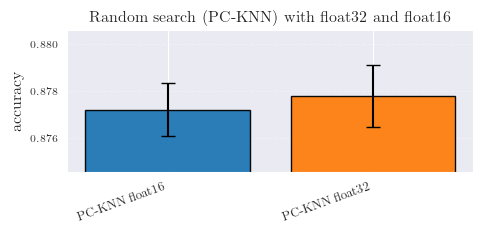


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\experiment_restrictive\resnet_small_random_knn_fp32_vs_fp16_summary.tex`

\begin{table}
\caption{resnet_small Random search (PC-KNN) with float32 and float16 (mean ± SE)}
\label{tab:resnet_small_random_knn_fp32_vs_fp16}
\begin{tabular}{lll}
\toprule
 & PC-KNN float16 & PC-KNN float32 \\
Metric &  &  \\
\midrule
accuracy & 0.8772 ± 0.0006 & 0.8778 ± 0.0007 \\
f2\_macro & 0.8755 ± 0.0006 & 0.8761 ± 0.0007 \\
f2\_micro & 0.8772 ± 0.0006 & 0.8778 ± 0.0007 \\
f2\_weighted & 0.8766 ± 0.0006 & 0.8772 ± 0.0007 \\
\bottomrule
\end{tabular}
\end{table}



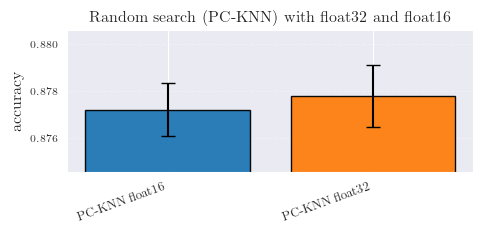


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\experiment_restrictive\resnet_small_random_knn_fp32_vs_fp16_summary.tex`

\begin{table}
\caption{resnet_small Random search (PC-KNN) with float32 and float16 (mean ± SE)}
\label{tab:resnet_small_random_knn_fp32_vs_fp16}
\begin{tabular}{lll}
\toprule
 & PC-KNN float16 & PC-KNN float32 \\
Metric &  &  \\
\midrule
accuracy & 0.8772 ± 0.0006 & 0.8778 ± 0.0007 \\
f2\_macro & 0.8755 ± 0.0006 & 0.8761 ± 0.0007 \\
f2\_micro & 0.8772 ± 0.0006 & 0.8778 ± 0.0007 \\
f2\_weighted & 0.8766 ± 0.0006 & 0.8772 ± 0.0007 \\
\bottomrule
\end{tabular}
\end{table}



In [77]:
groups_fp32 = [
    # Random search (PC-KNN) with float32 and float16
    ("random_knn_fp32_vs_fp16", "Random search (PC-KNN) with float32 and float16", [
        ("PC-KNN float16", f"{architecture}_random_search_default_domain_knn.json"),
        ("PC-KNN float32", f"{architecture}_random_search_default_domain_fp32_knn.json"),
    ]),
]
save_paths_fp32_pdf = [
    os.path.join(figure_path, f"{architecture}_random_knn_fp32_vs_fp16.pdf"),
]
save_paths_fp32_pgf = [
    os.path.join(figure_path, f"{architecture}_random_knn_fp32_vs_fp16.pgf"),
]
process_and_plot_groups(groups_fp32, base_results_dir, architecture, save_paths=save_paths_fp32_pdf)
process_and_plot_groups(groups_fp32, base_results_dir, architecture, save_paths=save_paths_fp32_pgf)

In [78]:
#count parameters of mode
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters in the model: {total_params}")

Total number of parameters in the model: 4902090


In [79]:
from torchinfo import summary
# Get a summary of the model
model_summary = summary(model, input_size=(1, 1, 40,40), verbose=0)
print(model_summary)

Layer (type:depth-idx)                        Output Shape              Param #
FlexibleResNet                                [1, 10]                   --
├─Conv2d: 1-1                                 [1, 64, 20, 20]           576
├─BatchNorm2d: 1-2                            [1, 64, 20, 20]           128
├─GELU: 1-3                                   [1, 64, 20, 20]           --
├─ModuleList: 1-4                             --                        --
│    └─Sequential: 2-1                        [1, 64, 20, 20]           --
│    │    └─BasicBlock: 3-1                   [1, 64, 20, 20]           73,984
│    └─Sequential: 2-2                        [1, 128, 10, 10]          --
│    │    └─BasicBlock: 3-2                   [1, 128, 10, 10]          230,144
│    └─Sequential: 2-3                        [1, 256, 5, 5]            --
│    │    └─BasicBlock: 3-3                   [1, 256, 5, 5]            919,040
│    └─Sequential: 2-4                        [1, 512, 3, 3]            --
│   

In [80]:
knn_single_pass_summary = summary(conf_mod_nn_pytorch_pretrained, input_size=(1, 1, 40,40), verbose=0)
print(knn_single_pass_summary)

Layer (type:depth-idx)                                  Output Shape              Param #
SinglePassConfidence                                    [1]                       --
├─ModelInputOutputWrapper: 1-1                          [1, 512]                  --
│    └─FlexibleResNet: 2-1                              [1, 10]                   --
│    │    └─Conv2d: 3-1                                 [1, 64, 20, 20]           576
│    │    └─BatchNorm2d: 3-2                            [1, 64, 20, 20]           128
│    │    └─GELU: 3-3                                   [1, 64, 20, 20]           --
│    │    └─ModuleList: 3-4                             --                        4,896,256
│    │    └─AdaptiveAvgPool2d: 3-5                      [1, 512, 1, 1]            --
│    │    └─Linear: 3-6                                 [1, 10]                   5,130
├─PredictedSplitConfidence: 1-2                         [1]                       --
│    └─PerClassKNNConfidence: 2-2               

In [81]:
from search.parallel_gradient import ParallelGradientDescent

pgd = ParallelGradientDescent(max_iterations=5, learning_rate=0.2, project_param=True, parallel_runs=6)
pgd_no_reflect = ParallelGradientDescent(max_iterations=5, learning_rate=0.2, project_param=True, parallel_runs=6,reflect=False)

In [82]:
#compare them
print("Starting pgd with reflection")
problem_knn= TransformationProblem(conf_mod_nn_pytorch_pretrained,transform_seq,
                                               consolidate_method="consolidate_simple")
complete_path = os.path.join(path, f"{architecture}_pgd_reflection_shgo_knn" + ".json")
load_or_run_evaluate_confidence_and_search(model, pgd, problem_knn, test_loader_transformed
                                             ,max_batch_override=1280,repeats=4,save_path=complete_path,overwrite=overwrite)

Starting pgd with reflection



{'repeats': 4,
 'accuracy_mean': 0.72284996509552,
 'accuracy_std': 0.005216962192207575,
 'accuracy_se': 0.0026084810961037874,
 'f2_macro_mean': 0.7174669504165649,
 'f2_macro_std': 0.005278083961457014,
 'f2_macro_se': 0.002639041980728507,
 'f2_micro_mean': 0.72284996509552,
 'f2_micro_std': 0.005216962192207575,
 'f2_micro_se': 0.0026084810961037874,
 'f2_weighted_mean': 0.720051646232605,
 'f2_weighted_std': 0.005224163644015789,
 'f2_weighted_se': 0.0026120818220078945,
 'per_run': [{'accuracy': 0.724399983882904,
   'f2_macro': 0.7188724279403687,
   'f2_micro': 0.724399983882904,
   'f2_weighted': 0.7214364409446716,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.7236999869346619,
   'f2_macro': 0.7184038162231445,
   'f2_micro': 0.7236999869346619,
   'f2_weighted': 0.7209205627441406,
   'per_sample_errors': None,
   'per_sample_matrices': Non

In [83]:
print("Starting pgd without reflection")
problem_knn= TransformationProblem(conf_mod_nn_pytorch_pretrained,transform_seq,
                                               consolidate_method="consolidate_simple")
complete_path = os.path.join(path, f"{architecture}_pgd_no_reflection_shgo_knn" + ".json")
load_or_run_evaluate_confidence_and_search(model, pgd_no_reflect, problem_knn, test_loader_transformed
                                             ,max_batch_override=1280,repeats=4,save_path=complete_path,overwrite=overwrite)
#

Starting pgd without reflection



{'repeats': 4,
 'accuracy_mean': 0.7122249603271484,
 'accuracy_std': 0.0010372193064540625,
 'accuracy_se': 0.0005186096532270312,
 'f2_macro_mean': 0.706579864025116,
 'f2_macro_std': 0.0010973616736009717,
 'f2_macro_se': 0.0005486808368004858,
 'f2_micro_mean': 0.7122249603271484,
 'f2_micro_std': 0.0010372193064540625,
 'f2_micro_se': 0.0005186096532270312,
 'f2_weighted_mean': 0.7090672850608826,
 'f2_weighted_std': 0.0009869987843558192,
 'f2_weighted_se': 0.0004934993921779096,
 'per_run': [{'accuracy': 0.7124999761581421,
   'f2_macro': 0.7067158222198486,
   'f2_micro': 0.7124999761581421,
   'f2_weighted': 0.7090885043144226,
   'per_sample_errors': None,
   'per_sample_matrices': None,
   'per_sample_true_labels': None,
   'per_sample_pred_labels': None,
   'per_sample_correct': None},
  {'accuracy': 0.7121000289916992,
   'f2_macro': 0.7065261602401733,
   'f2_micro': 0.7121000289916992,
   'f2_weighted': 0.7089439034461975,
   'per_sample_errors': None,
   'per_sample_mat

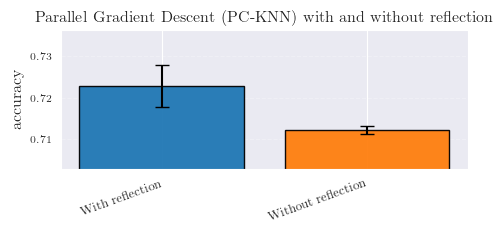


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\experiment_restrictive\resnet_small_pgd_knn_reflection_summary.tex`

\begin{table}
\caption{resnet_small Parallel Gradient Descent (PC-KNN) with and without reflection (mean ± SE)}
\label{tab:resnet_small_pgd_knn_reflection}
\begin{tabular}{lll}
\toprule
 & With reflection & Without reflection \\
Metric &  &  \\
\midrule
accuracy & 0.7228 ± 0.0026 & 0.7122 ± 0.0005 \\
f2\_macro & 0.7175 ± 0.0026 & 0.7066 ± 0.0005 \\
f2\_micro & 0.7228 ± 0.0026 & 0.7122 ± 0.0005 \\
f2\_weighted & 0.7201 ± 0.0026 & 0.7091 ± 0.0005 \\
\bottomrule
\end{tabular}
\end{table}



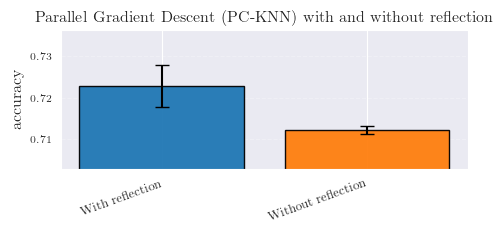


LaTeX written to: `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\bigger_mnist\experiment_restrictive\resnet_small_pgd_knn_reflection_summary.tex`

\begin{table}
\caption{resnet_small Parallel Gradient Descent (PC-KNN) with and without reflection (mean ± SE)}
\label{tab:resnet_small_pgd_knn_reflection}
\begin{tabular}{lll}
\toprule
 & With reflection & Without reflection \\
Metric &  &  \\
\midrule
accuracy & 0.7228 ± 0.0026 & 0.7122 ± 0.0005 \\
f2\_macro & 0.7175 ± 0.0026 & 0.7066 ± 0.0005 \\
f2\_micro & 0.7228 ± 0.0026 & 0.7122 ± 0.0005 \\
f2\_weighted & 0.7201 ± 0.0026 & 0.7091 ± 0.0005 \\
\bottomrule
\end{tabular}
\end{table}



In [84]:
#plot them
groups_pgd = [
    # Parallel Gradient Descent (PC-KNN) with and without reflection
    ("pgd_knn_reflection", "Parallel Gradient Descent (PC-KNN) with and without reflection", [
        ("With reflection", f"{architecture}_pgd_reflection_shgo_knn.json"),
        ("Without reflection", f"{architecture}_pgd_no_reflection_shgo_knn.json"),
    ]),
]
save_paths_pgd_pdf = [
    os.path.join(figure_path, f"{architecture}_pgd_knn_reflection.pdf"),
]
save_paths_pgd_pgf = [
    os.path.join(figure_path, f"{architecture}_pgd_knn_reflection.pgf"),
]
process_and_plot_groups(groups_pgd, base_results_dir, architecture, save_paths=save_paths_pgd_pdf)
process_and_plot_groups(groups_pgd, base_results_dir, architecture, save_paths=save_paths_pgd_pgf)

In [85]:
from utils.eval.ood_performance import ITSWRAPPER
import its.search
its2 = ITSWRAPPER(its.search.InverseTransformationSearch(model,None,None,n_hypotheses=1,n_samples=7,extend=0,gaussian_filter_channel_wise=True))
di = shgo.SHGO(local_max_steps=0,initial_samples=5)

In [86]:
print()
import random
#set random seeds
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
res1 = evaluate_confidence_and_search(model, di, problem_knn, test_loader_transformed
                                             ,max_batch_override=1280,repeats=2,store_val=True)

Eval (all repeats): 100%|██████████| 158/158 [00:09<00:00, 17.55it/s, Acc=0.529]


In [87]:
res1

{'repeats': 2,
 'accuracy_mean': 0.5225499868392944,
 'accuracy_std': 0.00898027140647173,
 'accuracy_se': 0.006350010808411814,
 'f2_macro_mean': 0.5121912360191345,
 'f2_macro_std': 0.009297004900872707,
 'f2_macro_se': 0.006573975210131657,
 'f2_micro_mean': 0.5225499868392944,
 'f2_micro_std': 0.00898027140647173,
 'f2_micro_se': 0.006350010808411814,
 'f2_weighted_mean': 0.5162153244018555,
 'f2_weighted_std': 0.008827741257846355,
 'f2_weighted_se': 0.00624215570598342,
 'per_run': [{'accuracy': 0.5162000060081482,
   'f2_macro': 0.5056172609329224,
   'f2_micro': 0.5162000060081482,
   'f2_weighted': 0.5099731683731079,
   'per_sample_errors': [-0.85595703125,
    -0.96533203125,
    -0.95703125,
    -0.8935546875,
    -0.95947265625,
    -0.927734375,
    -0.91748046875,
    -0.990234375,
    -0.93017578125,
    -0.94189453125,
    -0.99609375,
    -0.97705078125,
    -0.9951171875,
    -0.93408203125,
    -0.97705078125,
    -0.990234375,
    -0.94921875,
    -0.9658203125,
  

In [88]:
from utils.eval.ood_performance import evaluate_confidence_and_search2
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
print()
res2 = evaluate_confidence_and_search2(model, di, problem_knn, test_loader_transformed
                                             ,max_batch_override=1280,repeats=2,store_val=True)

Eval (all repeats):  99%|█████████▊| 156/158 [00:09<00:00, 16.63it/s, Acc=0.529, F2_mac=0.519, F2_mic=0.529, F2_w=0.522]


In [89]:
res2

{'repeats': 2,
 'accuracy_mean': 0.5225499868392944,
 'accuracy_std': 0.00898027140647173,
 'accuracy_se': 0.006350010808411814,
 'f2_macro_mean': 0.5121912360191345,
 'f2_macro_std': 0.009297004900872707,
 'f2_macro_se': 0.006573975210131657,
 'f2_micro_mean': 0.5225499868392944,
 'f2_micro_std': 0.00898027140647173,
 'f2_micro_se': 0.006350010808411814,
 'f2_weighted_mean': 0.5162153244018555,
 'f2_weighted_std': 0.008827741257846355,
 'f2_weighted_se': 0.00624215570598342,
 'per_run': [{'accuracy': 0.5162000060081482,
   'f2_macro': 0.5056172609329224,
   'f2_micro': 0.5162000060081482,
   'f2_weighted': 0.5099731683731079,
   'per_sample_errors': [-0.85595703125,
    -0.96533203125,
    -0.95703125,
    -0.8935546875,
    -0.95947265625,
    -0.927734375,
    -0.91748046875,
    -0.990234375,
    -0.93017578125,
    -0.94189453125,
    -0.99609375,
    -0.97705078125,
    -0.9951171875,
    -0.93408203125,
    -0.97705078125,
    -0.990234375,
    -0.94921875,
    -0.9658203125,
  

In [90]:
#compar res 1 and res 2